# 8 · Entraînement et test — solutions (notebook exécuté)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cemah2/workbookIA/blob/main/chapitres/ch08_train_test/05_solutions.ipynb)

Les réponses des exercices, exécutées. Les démarches détaillées (le *pourquoi*, les erreurs fréquentes, les variantes) sont dans `05_solutions.md`. Les cellules marquées `answer` enregistrent les réponses vérifiées par `wb.check` (`tools/build_answers.py`).

| Partie | ID | Titre | Type | ★ | ⏱️ |
|---|---|---|---|---|---|
| 0 | 8.Q1 à 8.Q11, 8.R1, 8.R2, 8.1 à 8.6, 8.8 | vérifier tes réponses courtes | 🧠 🔁 ✏️ ∂ 📈 | ★ à ★★★ | |
| A | 8.11 | train_test_split de scikit-learn : tailles, stratify, random_state | 📦 | ★ | 10 |
|  | 8.12 | Le modèle qui apprend par cœur : accuracy d'entraînement et de test | 🔮 | ★ | 15 |
|  | 8.13 | train_test_split from scratch | 🔨 | ★★ | 30 |
|  | 8.14 | Les indices de la k-fold : kfold_indices | 🔨 | ★★ | 25 |
|  | 8.15 | Reproduire la figure 8.13 : la rotation des folds | 🎨 | ★★ | 20 |
| B | 8.16 | Un estimateur maison à la scikit-learn : PolyFit(degree) | 🔨 | ★★ | 25 |
|  | 8.17 | Validation ou test : lequel sera le plus optimiste ? | 🔮 | ★★ | 15 |
|  | 8.18 | Boucle de sélection sur un jeu de validation : le degré du polynôme | 🔨 | ★★ | 30 |
|  | 8.19 | Données dépendantes : GroupKFold et TimeSeriesSplit | 📦 | ★★ | 25 |
|  | 8.20 | Écrire tes propres tests pytest pour train_test_split | 🛠️ | ★★ | 25 |
| C | 8.21 | k-fold stratifiée : stratified_kfold_indices | 🔨 | ★★★ | 40 |
|  | 8.22 | clone et cross_val_score | 🔨 | ★★★ | 45 |
|  | 8.23 | Variabilité de l'évaluation : hold-out répétés contre k-fold | 🔬 | ★★★ | 40 |
| D | 8.24 | Un notebook trop beau pour être vrai : quatre fuites à corriger | 🐛 | ★★★ | 35 |
|  | 8.25 | Sélectionner des features avant la validation croisée : 90 % sur du bruit | 🔬 | ★★★ | 40 |
|  | 8.26 | Comparer deux modèles honnêtement : test par permutation, p-valeur et bootstrap apparié | 🔬 | ★★★ | 40 |
|  | 8.27 | Défi : la meilleure paire de features, choisie sans toucher au test | 🏆 | ★★★ | 60 |

In [1]:
# ⚙️ SETUP: run this cell first (on Colab or on your computer)
FAST_MODE = True  # True = quick version (CPU, a few minutes); False = full version
SEED = 42

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/cemah2/workbookIA.git"
DRIVE_DIR = Path("/content/drive/MyDrive/workbookIA")

try:
    import google.colab  # noqa: F401  (this module only exists on Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    subprocess.run(["git", "config", "--global", "--add", "safe.directory", str(DRIVE_DIR)])
    if not (DRIVE_DIR / ".git").exists():
        subprocess.run(["git", "clone", REPO_URL, str(DRIVE_DIR)], check=True)
    else:
        # Get the new chapters. Your own work only lives in mon_travail/, which Claude never
        # touches, so "rebase + autostash" keeps it safe (even with local commits).
        identity = subprocess.run(["git", "-C", str(DRIVE_DIR), "config", "user.email"],
                                  capture_output=True).returncode == 0
        who = [] if identity else ["-c", "user.name=Workbook", "-c", "user.email=workbook@localhost"]
        pull = subprocess.run(["git", *who, "-C", str(DRIVE_DIR), "pull", "--rebase", "--autostash"],
                              capture_output=True, text=True)
        if pull.returncode != 0:
            print("⚠️ git pull a échoué (voir 00_setup/COLAB.md, « Problèmes fréquents ») :\n" + pull.stderr)
    ROOT = DRIVE_DIR
else:
    ROOT = Path(os.environ.get("WB_ROOT", Path.cwd())).resolve()
    while not (ROOT / "src" / "wb").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
    if not (ROOT / "src" / "wb").exists():
        raise FileNotFoundError("Dépôt introuvable : ouvre ce notebook depuis le dossier du workbook.")

os.environ["WB_ROOT"] = str(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import wb  # noqa: E402

cfg = wb.setup(seed=SEED, fast=FAST_MODE)
FAST_MODE = cfg.fast
mylearn = wb.load_mylearn("ref")  # reference implementation

🧪 Deep Learning Workbook : environnement
   Plateforme : Local (Linux x86_64, 2 CPU)
   Python 3.13.13 | numpy 2.1.3 | pandas 2.2.3 | matplotlib 3.10.0 | scikit-learn 1.6.1 | scipy 1.16.3 | torch 2.11.0+cpu | torchvision 0.26.0+cpu
   Device : cpu | Graine : 42 | FAST_MODE : True


## Objectifs et rappel express

- Découper des données en entraînement, validation et test, avec ou sans stratification.
- Programmer `train_test_split`, la k-fold simple et stratifiée, `clone` et `cross_val_score`.
- Choisir un hyperparamètre sur un jeu de validation, puis tester une seule fois.
- Reconnaître et corriger les fuites de données ; traiter les données dépendantes.
- Chiffrer l'incertitude d'un score et comparer deux modèles avec un test apparié.

**Rappel express.** $n_{\text{test}} = \lceil t \cdot n \rceil$ ; folds de $\lfloor n/k \rfloor + 1$ exemples pour les $n \bmod k$ premiers ; $\mathrm{SE} = \sqrt{\hat{p}(1-\hat{p})/n}$ ; $P(\max_j S_j \ge s) = 1 - (1 - P(S \ge s))^K$ ; $R^2 = 1 - SS_{\text{res}} / SS_{\text{tot}}$ ; p-valeur d'une permutation $(C + 1)/(n_{\text{perm}} + 1)$. En Python : `sklearn.model_selection` (`train_test_split`, `KFold`, `StratifiedKFold`, `GroupKFold`, `TimeSeriesSplit`, `cross_val_score`), `scipy.stats.binomtest`.

## Partie 0 · Vérifier tes réponses courtes (quiz, rappels, ✏️ 8.1 à 8.5, ∂ 8.6 et 📈 8.8)

Fais d'abord les quiz, les rappels et les exercices de `02_exercices.md` **sur papier**, dans ta copie de `06_mes_reponses.md`. Reporte ensuite chaque réponse courte ici : **la valeur** que tu as trouvée, pas l'expression Python, sinon tu ne vérifies rien. Un nombre : `42` ou `0.375` (en Python, le séparateur décimal est un **point** ; `0,375` sans guillemets serait un couple de deux nombres) ; un vrai ou faux : `True` ou `False` ; un choix : la lettre seule, entre guillemets (`"E"`) ; plusieurs choix : les lettres collées (`"AC"`) ; plusieurs nombres : une liste (`[2, 5]`). Arrondis comme l'énoncé le demande, et seulement à la fin du calcul. Les réponses pas encore remplies affichent ⏳. Les questions « dans ta copie », le quiz Q8, le rappel R3, la réflexion et l'entretien se corrigent avec `05_solutions.md`.

In [2]:
# The short answers only use the numbers of their statements (02_exercices.md)
import math

import numpy as np

# 8.1: the 344 penguins of the raw file
N_81, COUNTS_81 = 344, {"Adelie": 152, "Chinstrap": 68, "Gentoo": 124}
TEST_81 = math.ceil(0.2 * N_81)                                    # 60/20/20: the test first...
VAL_81 = math.ceil(0.25 * (N_81 - TEST_81))                        # ...then the validation in the rest


def largest_remainder(counts, n_part, n_total):
    """Number of samples of each class in a stratified part of n_part samples (largest remainder rule)."""
    exact = np.array(counts) * n_part / n_total
    base = np.floor(exact).astype(int)
    base[np.argsort(-(exact - base), kind="stable")[: n_part - base.sum()]] += 1
    return base.tolist()


# 8.4: standard error of an accuracy
P_84, N_84 = 0.92, 250
SE_84 = math.sqrt(P_84 * (1 - P_84) / N_84)

# 8.5: the scores of two models on the same 5 folds
A_85 = np.array([0.82, 0.88, 0.79, 0.85, 0.86])
B_85 = np.array([0.85, 0.84, 0.86, 0.85, 0.83])

# 8.6: the best of K independent validation scores
Q_86 = 0.0668

**8.Q1 — La boucle d'entraînement : prédire, comparer, corriger**

In [3]:
wb.record("8.Q1a", "B", mistakes={"c'est le comportement d'un modèle qui minimise une loss (question d) ; la boucle simplifiée du livre ne corrige que les erreurs": "A",
          "l'exemple reste dans le jeu d'entraînement : il resservira à l'epoch suivante": "C",
          "une epoch ne s'arrête qu'après le passage de tous les exemples": "D"})
wb.record("8.Q1b", "C", mistakes={"le label seul ne dit pas dans quel sens corriger : il faut aussi savoir ce que le modèle a répondu": "A",
          "le jeu de test ne sert jamais à corriger le modèle (§8.3)": "B",
          "la correction porte sur l'exemple qu'on vient de traiter": "D"})
wb.record("8.Q1c", True, mistakes={"pendant le test, l'erreur sert seulement à compter : rien ne remonte vers les paramètres": False})

WB_ANSWER {"hash": "b3fd6d8ba0417f6d3efc80c054bea03cb89b7430b7eba0772c0c7632190bbf1f", "id": "8.Q1a", "kind": "str", "mistakes": {"02ecf91879e1be4936b33a0c35814a68bdfdcfa57ba5d2d8992c4cba0d676857": "une epoch ne s'arrête qu'après le passage de tous les exemples", "c67414022c86a7fa769951d05ec0b069ae2ab6150b34edda27bcab8a137469c1": "l'exemple reste dans le jeu d'entraînement : il resservira à l'epoch suivante", "edff795395186f9183e2057944147d80878c9e0a2a3e4aeb5b711c0957a84e2f": "c'est le comportement d'un modèle qui minimise une loss (question d) ; la boucle simplifiée du livre ne corrige que les erreurs"}}
📝 Ex 8.Q1a : réponse enregistrée (str).
WB_ANSWER {"hash": "dd5c31dca7f2d73326d8883403f0623cef1956e935fdf114a3aa8bf76c2c6083", "id": "8.Q1b", "kind": "str", "mistakes": {"8c9780a43d33d8bb06c87bac10484b283a0e6afc46b1a629ae780ba16ab95b17": "le jeu de test ne sert jamais à corriger le modèle (§8.3)", "a70e9decc489b554151103ecf270281f680dd97a05766915ad4535ccaf5130db": "le label seul ne di

**8.Q2 — Epoch, ordre des exemples et fréquence des mises à jour**

In [4]:
wb.record("8.Q2a", 1200 * 5, mistakes={"une mise à jour par exemple, et chaque epoch présente tous les exemples : combien d'exemples en tout ?": 1200,
          "c'est le nombre de mises à jour en 5 epochs avec des mini-batches : ici, une mise à jour par exemple": 95})
wb.record("8.Q2b", math.ceil(1200 / 64), fractional="un nombre de mises à jour est entier : le dernier mini-batch, plus petit, compte quand même pour une mise à jour",
          mistakes={"le dernier mini-batch, plus petit, compte aussi pour une mise à jour": 18})
wb.record("8.Q2c", True, mistakes={"une epoch est un passage complet sur le jeu d'entraînement : chaque exemple y est vu une fois": False})
wb.record("8.Q2d", "A", mistakes={"mélanger ne crée aucun exemple nouveau": "B",
          "le jeu de test n'intervient pas pendant l'entraînement": "C",
          "l'algorithme de mise à jour fonctionne quel que soit l'ordre ; c'est le modèle qui risque de s'adapter à cet ordre": "D"})

WB_ANSWER {"hash": "5f7ac6caf200f2f34b5a4808f2f864d39d0581fa424a58cd2aa88175f4b27983", "id": "8.Q2a", "kind": "int", "magnitude": 3, "mistakes": {"b1bdcf6689076cbea84d9c951901cfbbe990423eee53a39e7192a5caa904de91": "une mise à jour par exemple, et chaque epoch présente tous les exemples : combien d'exemples en tout ?", "d94fa52c308dbf77b8e4c7fc06a827e741fdf644f624c2fa3b6f840404b96518": "c'est le nombre de mises à jour en 5 epochs avec des mini-batches : ici, une mise à jour par exemple"}, "sign": 1}
📝 Ex 8.Q2a : réponse enregistrée (int).
WB_ANSWER {"fractional": "un nombre de mises à jour est entier : le dernier mini-batch, plus petit, compte quand même pour une mise à jour", "hash": "2800b3c08e397601bd59b99566ba64addf90a08f61db516a4e27ccbda2b3c823", "id": "8.Q2b", "kind": "int", "magnitude": 1, "mistakes": {"c3d4e142235cd772a40b9c1b351e8a0fd36b59422e9919992766ae3313387a0e": "le dernier mini-batch, plus petit, compte aussi pour une mise à jour"}, "sign": 1}
📝 Ex 8.Q2b : réponse enregis

**8.Q3 — 99 % sur l'entraînement : que peut-on vraiment conclure ?**

In [5]:
wb.record("8.Q3a", "C", mistakes={"le score d'entraînement ne prédit pas le score sur des données nouvelles (§8.2.1)": "A",
          "« forcément » est trop fort : un raccourci est possible, pas certain": "B",
          "viser 100 % sur l'entraînement n'apprend rien sur la généralisation": "D"})
wb.record("8.Q3b", False, mistakes={"relis la fin du §8.2.1 : il faut essayer le modèle pour le savoir": True})
wb.record("8.Q3c", "A", mistakes={"les paramètres seuls ne disent pas comment le modèle se comportera sur des données nouvelles": "B",
          "le nombre de paramètres ne mesure pas la performance": "C",
          "un autre entraînement donnerait un autre modèle, pas une mesure du premier": "D"})

WB_ANSWER {"hash": "de11cff87819900ebe2bac27a84b8ddacd478fbc4f00ed619804f1c7d6f968b7", "id": "8.Q3a", "kind": "str", "mistakes": {"43e7c56bd9643a50d2f32cf2dfc4b48d3e1c01c62d21ed8bd86bbd66906ee272": "le score d'entraînement ne prédit pas le score sur des données nouvelles (§8.2.1)", "64da7f5e072d605aa32a03438a57ae0ecf51c68510d2e5f4d771c138fbf9efd6": "« forcément » est trop fort : un raccourci est possible, pas certain", "f014a956e95ed431a9476325e2ebbe35656a57634298e936babb42f9f68eec89": "viser 100 % sur l'entraînement n'apprend rien sur la généralisation"}}
📝 Ex 8.Q3a : réponse enregistrée (str).
WB_ANSWER {"hash": "afafbdfa17efc51f748f52c3a18c30dc8f8bd6b01829ccc57cdaff66839a2a33", "id": "8.Q3b", "kind": "bool", "mistakes": {"ae18fea43b28dbaacd33d19cb23708a9d00b94c380a2fba24fc99559300795cd": "relis la fin du §8.2.1 : il faut essayer le modèle pour le savoir"}}
📝 Ex 8.Q3b : réponse enregistrée (bool).
WB_ANSWER {"hash": "500cdf35ee096639779fb64cf9547bdc16d790f5afc2bce768ea9725aa96e477", 

**8.Q4 — Le renard et la neige : repérer un raccourci appris**

In [6]:
wb.record("8.Q4a", "B", mistakes={"le pelage distingue vraiment les deux animaux : ce n'est pas un raccourci": "A",
          "la forme des oreilles est une vraie différence entre renards et chats": "C",
          "la taille sur la photo dépend du cadrage, mais quel détail accompagne TOUJOURS une classe dans ces données ?": "D"})
wb.record("8.Q4b", False, mistakes={"si le test vient du même lot, le décor y accompagne toujours la même classe : le raccourci y marche aussi": True})
wb.record("8.Q4c", "C", mistakes={"un renard dans la neige est le cas où le raccourci et la vérité sont d'accord": "A",
          "un chat dans un salon est aussi un cas où le raccourci donne la bonne réponse": "B",
          "un renard en forêt ressemble à toutes les photos d'entraînement": "D"})

WB_ANSWER {"hash": "add5e402435bd32cc5d357260425f222fe72d7a2c2cf2da647fc8e2c576055b4", "id": "8.Q4a", "kind": "str", "mistakes": {"5a6237afe03fa709b42fa2a8ddcbe13f5d79fad3ce4a241109e222d2b4dfbf8f": "la forme des oreilles est une vraie différence entre renards et chats", "9b6ed76d30d8e29fa48a7ad27a5fb07a4c2ea19e3b449c98197e82fcbf49b89b": "le pelage distingue vraiment les deux animaux : ce n'est pas un raccourci", "d694e0b945b36115841d707b53eb832eb9df15f0f6077cdd5faa65b6e7f79cd1": "la taille sur la photo dépend du cadrage, mais quel détail accompagne TOUJOURS une classe dans ces données ?"}}
📝 Ex 8.Q4a : réponse enregistrée (str).
WB_ANSWER {"hash": "cb27ac41a3f5c5ec239c3129e4ece101307be4e25dd9afce0afbde701b3a2e93", "id": "8.Q4b", "kind": "bool", "mistakes": {"94edd54187b31418be18d360fadcd848731f1a27f9a101937202cb907f0149fd": "si le test vient du même lot, le décor y accompagne toujours la même classe : le raccourci y marche aussi"}}
📝 Ex 8.Q4b : réponse enregistrée (bool).
WB_ANSWER {"h

**8.Q5 — La règle d'or du jeu de test**

In [7]:
wb.record("8.Q5a", False, mistakes={"choisir en regardant le test, c'est déjà s'en servir pour construire le modèle": True})
wb.record("8.Q5b", True, mistakes={"relis le §8.3 : combien de fois le livre veut-il qu'on utilise le test ?": False})
wb.record("8.Q5c", False, mistakes={"ces deux nombres transforment les données d'entraînement : ils font partie du modèle, au sens large": True})
wb.record("8.Q5d", True, mistakes={"le test doit estimer la performance en déploiement : il doit donc y ressembler": False})

WB_ANSWER {"hash": "00351f0736d519320e5d46d53a6001aad10b13d48e076d56af709fd24866f5aa", "id": "8.Q5a", "kind": "bool", "mistakes": {"885ef4fe7da18fe1ab4a68ad5f8c12c4048eae6d34251ff9bdb7d4e8271c0691": "choisir en regardant le test, c'est déjà s'en servir pour construire le modèle"}}
📝 Ex 8.Q5a : réponse enregistrée (bool).
WB_ANSWER {"hash": "8c2c174229db3749632bb5028a6402e66626c5f95dbe6657b3d5f725936132f5", "id": "8.Q5b", "kind": "bool", "mistakes": {"e81bc7f07d3eae6ca13e8c866267c20bb6cc0619f693fe507be9bb1c9a45a1ca": "relis le §8.3 : combien de fois le livre veut-il qu'on utilise le test ?"}}
📝 Ex 8.Q5b : réponse enregistrée (bool).
WB_ANSWER {"hash": "87a00a0533e592501f901333a8efb7f8fdc7a57c138c9984fd8f25235d43f6ec", "id": "8.Q5c", "kind": "bool", "mistakes": {"4a60d92d158ac5992680ad9b3914eb61e5d67d97817500f9c097976eece05193": "ces deux nombres transforment les données d'entraînement : ils font partie du modèle, au sens large"}}
📝 Ex 8.Q5c : réponse enregistrée (bool).
WB_ANSWER {"hash

**8.Q6 — Fuite de données : ses formes courantes**

In [8]:
wb.record("8.Q6a", "BDE", mistakes={"retirer les doublons avant de découper empêche au contraire une fuite": "ABDE",
          "ajuster la standardisation sur l'entraînement seulement, puis l'appliquer au test, est la bonne pratique": "BCDE",
          "une des pratiques restantes utilise une information qu'on n'aura pas au moment de prédire": "BD",
          "des radios du même patient des deux côtés du découpage, est-ce une fuite ?": "BE",
          "comment les 20 features ont-elles été choisies ?": "DE"})

WB_ANSWER {"hash": "a9bb8f3f77952403ed0982dd15a668a7fe444e23d22ba5508ae10e7d4beb7945", "id": "8.Q6a", "kind": "str", "mistakes": {"32c328abcab2fa1a8774728b42c1e71092da17baeb7287eaca3046e112d2a6d2": "comment les 20 features ont-elles été choisies ?", "36b1467a90db60ee7e53d30710e26433223bfa891a2e06c962d85360cf839feb": "des radios du même patient des deux côtés du découpage, est-ce une fuite ?", "55399d418cca56d8180adaf0924722a689aef91482c8dd770384c93d4c53b294": "ajuster la standardisation sur l'entraînement seulement, puis l'appliquer au test, est la bonne pratique", "8bef115966e008be198d3a6e377faa85e7a4476e8d3936e11666c5174700a97e": "une des pratiques restantes utilise une information qu'on n'aura pas au moment de prédire", "97304b4e3dceab9c7f16f50bf56b3a6365a258f0f34d8a336b0837e3ea600441": "retirer les doublons avant de découper empêche au contraire une fuite"}}
📝 Ex 8.Q6a : réponse enregistrée (str).


**8.Q7 — Pourquoi un jeu de validation en plus du test ?**

In [9]:
wb.record("8.Q7a", "D", mistakes={"le jeu de validation PREND des données à l'entraînement : il n'en ajoute pas": "A",
          "la validation ne remplace pas le test : les deux coexistent": "B",
          "relis le §8.4 : à quoi sert la boucle de la figure 8.9 ?": "C"})
wb.record("8.Q7b", int(0.6 * 500), mistakes={"60 % + 20 % : c'est le réentraînement final, une fois la recherche terminée ; pendant la recherche, la validation ne fait que noter": 400,
          "c'est la taille de la validation (ou du test)": 100})
wb.record("8.Q7c", True, mistakes={"chaque réglage apprend ses paramètres sur l'entraînement ; la validation ne sert qu'à le noter": False})

WB_ANSWER {"hash": "c205dd7bea458c9142a0ec54d3ac76077992e7088a6d71e2f0b5e5c250b53945", "id": "8.Q7a", "kind": "str", "mistakes": {"6ebf824b63efbea756a47684e5ec2962c5707b62b0ec54efab1545b8a486b7c0": "la validation ne remplace pas le test : les deux coexistent", "93bb0adebef80ea941c964e11757548a167f131c07d94fce2dd599af19a859fa": "le jeu de validation PREND des données à l'entraînement : il n'en ajoute pas", "b279c9a70e0fb568a9174115031dbc679a88f5c0fd26b87e7b8b503a9e3a7349": "relis le §8.4 : à quoi sert la boucle de la figure 8.9 ?"}}
📝 Ex 8.Q7a : réponse enregistrée (str).
WB_ANSWER {"hash": "5d0df3ace4af7f945e1c6ea2da51aec1033356d823c980136792083020faae42", "id": "8.Q7b", "kind": "int", "magnitude": 2, "mistakes": {"33287621c482daf57361113ec159941a875997c97ece06c416afdd968ecf964b": "60 % + 20 % : c'est le réentraînement final, une fois la recherche terminée ; pendant la recherche, la validation ne fait que noter", "920caf4211035c83ea24efdb87928ad80117eb82b00af587640bdf9203d72c57": "c'es

**8.Q9 — Validation croisée : ce qu'on moyenne, et pourquoi**

In [10]:
wb.record("8.Q9a", "A", mistakes={"on moyenne des mesures de performance, pas des prédictions": "B",
          "les modèles des différents tours ne sont pas combinés entre eux": "C",
          "un score d'entraînement ne dit rien de la généralisation (§8.2.1)": "D"})
wb.record("8.Q9b", True, mistakes={"si le modèle gardait ce qu'il a appris au tour précédent, il aurait déjà vu le fold de validation": False})
wb.record("8.Q9c", "B", mistakes={"le test est mis de côté AVANT la validation croisée (§8.5)": "A",
          "le test reste nécessaire, pour l'évaluation finale": "C",
          "à quoi servent les folds de validation temporaires ?": "D"})

WB_ANSWER {"hash": "1a7e23f8195259b6dce51edd49d3f5c9b4972d4da6d3c29e70926627a4193dbe", "id": "8.Q9a", "kind": "str", "mistakes": {"066ce25b36e72b52645dc961f91bcd5d2443add46f2b70cada21b4b7808b13de": "les modèles des différents tours ne sont pas combinés entre eux", "29e21c7ad2ae1d77b3d126353e074c4a09ec806f4b7d67da97604c8ce4561d6e": "un score d'entraînement ne dit rien de la généralisation (§8.2.1)", "75945a31dc4e3c54ba1482896ae3f3cf4c025e4042c5a0fdf80f7d8e5fb2b462": "on moyenne des mesures de performance, pas des prédictions"}}
📝 Ex 8.Q9a : réponse enregistrée (str).
WB_ANSWER {"hash": "b1b60979491fdf68f04a982b0be0e3b3ac9b51f8bb0687822a7a641eb8b8b562", "id": "8.Q9b", "kind": "bool", "mistakes": {"5c447e0f1ed368e8bf007156bd0a8e55e24470b891d750629fe20f86a09a66c6": "si le modèle gardait ce qu'il a appris au tour précédent, il aurait déjà vu le fold de validation"}}
📝 Ex 8.Q9b : réponse enregistrée (bool).
WB_ANSWER {"hash": "aaea1aedd0cac0c7abb80c65a4feaa0cccbdb9298bea27a26f6baa3b5ef9f165"

**8.Q10 — k-fold : combien d'entraînements, quelle taille de fold ?**

In [11]:
wb.record("8.Q10a", 5, mistakes={"un entraînement par fold de validation : combien de folds ?": 1})
wb.record("8.Q10b", 1003 // 5 + 1, fractional="un fold contient un nombre entier d'exemples : écris 1003 = 5 × q + r",
          mistakes={"c'est la taille des derniers folds : les premiers en reçoivent un de plus": 200})
wb.record("8.Q10c", 1003 % 5, mistakes={"c'est le nombre de folds de la petite taille": 2})
wb.record("8.Q10d", 1003 - 1003 // 5, mistakes={"le fold 5 fait-il partie des grands folds ou des petits ?": 802,
          "il faut retirer le fold de validation": 1003})
wb.record("8.Q10e", 1003, mistakes={"un exemple par fold : combien de folds ?": 1})

WB_ANSWER {"hash": "1f3ae8f77c6adb7b76b6f834e04a55ec59dfaf5d061cd4b5ae17a701ac64c3cb", "id": "8.Q10a", "kind": "int", "magnitude": 0, "mistakes": {"8de6955ca56ca5ea92db7a0becd75fd7b970fd7c7dacf5daff0e4a525e6c5573": "un entraînement par fold de validation : combien de folds ?"}, "sign": 1}
📝 Ex 8.Q10a : réponse enregistrée (int).
WB_ANSWER {"fractional": "un fold contient un nombre entier d'exemples : écris 1003 = 5 × q + r", "hash": "ed00c13fb142c100f896d934ec1d7b74bc8892f0fb70467b7405625330a52194", "id": "8.Q10b", "kind": "int", "magnitude": 2, "mistakes": {"27f65256ec3abb9c2f1dd0944331acad4107f5999cb31429d5a543b05c0e2989": "c'est la taille des derniers folds : les premiers en reçoivent un de plus"}, "sign": 1}
📝 Ex 8.Q10b : réponse enregistrée (int).
WB_ANSWER {"hash": "ba2bfb8f1e159f552cdf38fb0c9d1069d6e924841126dd8f87de5149ac4a8938", "id": "8.Q10c", "kind": "int", "magnitude": 0, "mistakes": {"f2705c0ef4acc940bb1820c0cbbd4e84cedb99df9c01cbaa0ee1c7fbcf7b9df5": "c'est le nombre de fo

**8.Q11 — Les deux usages des résultats de test**

In [12]:
wb.record("8.Q11a", "AE", mistakes={"l'un des deux usages a lieu PENDANT l'entraînement (§8.6)": "AC",
          "l'un des deux usages a lieu AVANT le déploiement (§8.6)": "CE"})
wb.record("8.Q11b", True, mistakes={"le nouveau réglage a été choisi après avoir vu le score de test : le test a servi à choisir": False})

WB_ANSWER {"hash": "957221d8d5e9d739fdea461116d935d7a540b780b0018477e26951c28fcc5d1a", "id": "8.Q11a", "kind": "str", "mistakes": {"b16080d1915f2e35e76ce89b829a4f057f1f674f2b238e026e63aaaac7c956a1": "l'un des deux usages a lieu AVANT le déploiement (§8.6)", "ea71b98e01287564e14ee7f28740c5d37a04d37ff72d3da598c261388ab44170": "l'un des deux usages a lieu PENDANT l'entraînement (§8.6)"}}
📝 Ex 8.Q11a : réponse enregistrée (str).
WB_ANSWER {"hash": "41b87d240b67bb5ccc33d8829261dd988356ea3306990fdadbf0b34cade6053a", "id": "8.Q11b", "kind": "bool", "mistakes": {"08ef25d118bbd57103be331a171878f73b42cb23d1c212052b8e5434bf681f89": "le nouveau réglage a été choisi après avoir vu le score de test : le test a servi à choisir"}}
📝 Ex 8.Q11b : réponse enregistrée (bool).


**8.R1 — Ch. 7 : pourquoi l'inertie seule ne permet pas de choisir k**

In [13]:
wb.record("8.R1a", 0, mistakes={"chaque point est son propre centre : quelle est sa distance à ce centre ?": 200})
wb.record("8.R1b", True, mistakes={"avec un cluster de plus, on peut toujours garder les anciens centres et en ajouter un : l'inertie ne peut pas augmenter": False})
wb.record("8.R1c", "C", mistakes={"c'est justement le critère qui baisse mécaniquement": "A",
          "le nombre d'itérations ne juge pas la qualité des clusters": "B",
          "c'est un autre nom de l'inertie": "D"})

WB_ANSWER {"hash": "6d978c400e1d9ea1927ae7a17d89b9a754099705c327e87bb74b1d2710db9445", "id": "8.R1a", "kind": "int", "magnitude": null, "mistakes": {"6f08a6b11f348d94cdeba6cf562f44da752d1e0e2a8f170901ab6e0ec2d070a8": "chaque point est son propre centre : quelle est sa distance à ce centre ?"}, "sign": 0}
📝 Ex 8.R1a : réponse enregistrée (int).
WB_ANSWER {"hash": "fa64098143158b8c8cbb3c104af1d9fd5e7f402e3cd3cc0bc638a00baa250b23", "id": "8.R1b", "kind": "bool", "mistakes": {"a512b864d5525a92854780742d80892dec0428b0346374479037456d12a1c32c": "avec un cluster de plus, on peut toujours garder les anciens centres et en ajouter un : l'inertie ne peut pas augmenter"}}
📝 Ex 8.R1b : réponse enregistrée (bool).
WB_ANSWER {"hash": "7fe2becf4e3c932b109803c8322ebcfaae4ac1bffaaea74268476019141783ae", "id": "8.R1c", "kind": "str", "mistakes": {"082915f6630232ca06a4bcab12d71fe996fd5eafd861e59aed9cab13fa2ac663": "le nombre d'itérations ne juge pas la qualité des clusters", "18d1cf4bd5dae056e3af712594644

**8.R2 — Ch. 5 : un pas de descente de gradient à la main**

In [14]:
wb.record("8.R2a", (0.5 * 2 - 3) ** 2, decimals=2, mistakes={"c'est l'erreur w0·x − y : la loss est son carré": -2,
          "la loss est le carré de l'erreur, pas sa valeur absolue": 2})
wb.record("8.R2b", 2 * 2 * (0.5 * 2 - 3), decimals=2, mistakes={"regarde le signe de w0·x − y": 8,
          "n'oublie pas le facteur x de la dérivée de w·x": -4})
wb.record("8.R2c", 0.5 - 0.05 * (2 * 2 * (0.5 * 2 - 3)), decimals=2, mistakes={"on retranche η × L'(w0), et L'(w0) est négatif : w doit augmenter": 0.1})
wb.record("8.R2d", (0.9 * 2 - 3) ** 2, decimals=2, mistakes={"c'est l'erreur w1·x − y : la loss est son carré": -1.2})

WB_ANSWER {"decimals": 2, "hash": "1d316af7a616ac58eeae631cd31944a17c74ff258f960f0ac74eb842a77ccd5a", "hash_coarse": "19fea9cc09937534ca0682b15064db739dc0d1db77add9f712204fe7c7d598be", "id": "8.R2a", "kind": "float", "magnitude": 0, "mistakes": {"68e17326826e1185060b7f1c87c1e8f469a410fba9491747fdaeafea866f3989": "c'est l'erreur w0·x − y : la loss est son carré", "a2af6179e3bf19a6629c0a0d0ee24e894bfae74ee77f1f476ce8944f16892017": "la loss est le carré de l'erreur, pas sa valeur absolue"}, "sign": 1}
📝 Ex 8.R2a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 2, "hash": "2839d7417c891d45cca3912b37bb966dc19afe01f4ec4983b498311278fa39c6", "hash_coarse": "aa506272566d8c5431a6d9623032c92f96f837d03511f0b4a6934866705ded2b", "id": "8.R2b", "kind": "float", "magnitude": 0, "mistakes": {"535e84f1a2a9dd35e1527f7c547ad4f034ae8db2fa5e51676a166d54a6324473": "n'oublie pas le facteur x de la dérivée de w·x", "b8b1d2133555e9f2596febd3c57f164bb9db185638f073c7c40bc52a3cad5743": "regard

**Ex 8.1 — Découper 344 manchots : hold-out, validation et folds**

In [15]:
wb.record("8.1a", math.ceil(0.25 * N_81), mistakes={"c'est la taille de l'entraînement : la question demande le test": 258})
wb.record("8.1b", N_81 - math.ceil(0.25 * N_81), mistakes={"c'est la taille du test : la question demande l'entraînement": 86})
wb.record("8.1c", TEST_81, fractional="une taille est un nombre entier : applique l'arrondi de la règle",
          mistakes={"0,2 × 344 = 68,8 : la règle arrondit la taille du test vers le haut": 68})
wb.record("8.1d", VAL_81, fractional="une taille est un nombre entier : applique l'arrondi de la règle",
          mistakes={"la validation se prend dans les manchots qui restent, avec t = 0,25": 55,
                    "0,25 × 275 = 68,75 : la règle arrondit vers le haut": 68})
wb.record("8.1e", N_81 - TEST_81 - VAL_81, mistakes={"la validation compte ⌈0,25 × 275⌉ manchots": 207,
          "il faut encore retirer la validation": 275})
wb.record("8.1f", (N_81 - TEST_81) // 5, fractional="un fold contient un nombre entier de manchots",
          mistakes={"la validation croisée s'applique aux manchots qui restent une fois le test mis de côté": 69})
wb.record("8.1g", N_81 % 10, mistakes={"ce sont les folds de 34 : la question demande ceux de 35": 6})
wb.record("8.1h", N_81 - (N_81 // 10 + 1), mistakes={"au premier tour, le fold 1 sert de validation : quelle est sa taille ?": 310,
          "il faut retirer le fold de validation": 344})
wb.record("8.1i", largest_remainder([COUNTS_81[s] for s in ('Adelie', 'Chinstrap', 'Gentoo')], TEST_81, N_81), mistakes={"le total doit faire 69 : il manque des manchots, à donner aux plus grandes parties décimales": [30, 13, 24],
          "le total doit faire 69 : un manchot de trop": [31, 14, 25],
          "l'ordre demandé est Adélie, Chinstrap, Gentoo": [30, 25, 14]})

WB_ANSWER {"hash": "d301fe0f0d12d765515b93fb9acb478bbcce134d6cf8f27f2a7b96d56cd033a5", "id": "8.1a", "kind": "int", "magnitude": 1, "mistakes": {"49db111cc35a99b163d8e5beb529899573a049b86587b049129d21ecf2cb3beb": "c'est la taille de l'entraînement : la question demande le test"}, "sign": 1}
📝 Ex 8.1a : réponse enregistrée (int).
WB_ANSWER {"hash": "340b71406fdb841d57cd3f01ada53b68d8fa4817d8a224e238025fdcd538e2e0", "id": "8.1b", "kind": "int", "magnitude": 2, "mistakes": {"a1baa778df8d073aeba746b4aa5b2af59ef0e71a50ac08f0097308be9785c576": "c'est la taille du test : la question demande l'entraînement"}, "sign": 1}
📝 Ex 8.1b : réponse enregistrée (int).
WB_ANSWER {"fractional": "une taille est un nombre entier : applique l'arrondi de la règle", "hash": "0f45911f5e1324f7ba7ad4ec7470c6de1ce120346ddd939c571c38327518b868", "id": "8.1c", "kind": "int", "magnitude": 1, "mistakes": {"75e8541877b75e24f418ec7b9115ae31759f625c2efa05289fb270f75c0dcc12": "0,2 × 344 = 68,8 : la règle arrondit la taill

**Ex 8.2 — Compter les entraînements d'une recherche d'hyperparamètres**

In [16]:
wb.record("8.2a", 3 * 4 * 2, mistakes={"chaque valeur de l'un se combine avec chaque valeur des autres : on multiplie, on n'additionne pas": 9})
wb.record("8.2b", 24, mistakes={"un seul entraînement par réglage avec un jeu de validation fixe": 120})
wb.record("8.2c", 24 * 5, mistakes={"chaque réglage est entraîné une fois par fold": 24,
          "il y a 5 tours, pas 4 : chaque fold sert une fois de validation": 96})
wb.record("8.2d", 24 * 5 + 1, mistakes={"un seul réentraînement final, celui du réglage retenu": 144,
          "n'oublie pas le réentraînement final": 120})
wb.record("8.2e", 121 * 4 / 60, decimals=1, mistakes={"121 entraînements de 4 minutes, puis la conversion en heures": 2.0,
          "n'oublie pas le réentraînement final de d) : 121 entraînements, pas 120": 8.0})
wb.record("8.2f", 5 * (24 * 5 + 1), mistakes={"dans chaque tour extérieur, le réglage retenu est aussi réentraîné": 600,
          "il y a 5 tours extérieurs": 121,
          "compte seulement le protocole décrit : la validation croisée imbriquée n'ajoute pas de réentraînement final sur toutes les données": 606})
wb.record("8.2g", (200 - 1) // 5, fractional="un nombre de réglages est entier : garde ceux qui tiennent dans le budget",
          mistakes={"n'oublie pas le réentraînement final, qui prend un entraînement du budget": 40})

WB_ANSWER {"hash": "9bfea4e507bf7502d124afaba0c21b5c3a410d7aabac7d98995edde5e60f6ab5", "id": "8.2a", "kind": "int", "magnitude": 1, "mistakes": {"3ff54212d1a02fd2274f2f52e99e287d7612862687774f391985f2b2791dfe7c": "chaque valeur de l'un se combine avec chaque valeur des autres : on multiplie, on n'additionne pas"}, "sign": 1}
📝 Ex 8.2a : réponse enregistrée (int).
WB_ANSWER {"hash": "fdc39d6846bc1edd06db6ca5bc344125c4aab532171784aeaa6f6667563bad95", "id": "8.2b", "kind": "int", "magnitude": 1, "mistakes": {"c8c33ec73baa281ecd58d8a76edc52fbc90b7e25093a08b6d968c724a6b825a0": "un seul entraînement par réglage avec un jeu de validation fixe"}, "sign": 1}
📝 Ex 8.2b : réponse enregistrée (int).
WB_ANSWER {"hash": "742cb56b8c5701234876441085198007d7ca2e55bc999667ea7f6aa07058e3e6", "id": "8.2c", "kind": "int", "magnitude": 2, "mistakes": {"2b1b1d7ff5e56649bf186bdfde6d9e3e1cfde23358431c25faa681b3e67ae1f3": "il y a 5 tours, pas 4 : chaque fold sert une fois de validation", "9e5cb83d0e06dbc082ebfe

**Ex 8.3 — Fuite ou pas ? Six protocoles à auditer**

In [17]:
wb.record("8.3a", True, mistakes={"la médiane a été calculée sur toutes les annonces, test compris": False})
wb.record("8.3b", False, mistakes={"la standardisation est ajustée sur les seules images d'entraînement, et le test est un fichier à part": True})
wb.record("8.3c", True, mistakes={"le réglage a été choisi en regardant le test, puis son score publié": False})
wb.record("8.3d", True, mistakes={"pour prévoir un mois, le modèle aura-t-il, en production, les mois qui le suivent ?": False})
wb.record("8.3e", False, mistakes={"tous les enregistrements d'un locuteur sont dans le même fold : c'est le bon découpage ici": True})
wb.record("8.3f", True, mistakes={"cette information sera-t-elle connue au moment où l'on doit prédire ?": False})

WB_ANSWER {"hash": "0ed465f5b019e4108c25cd8fac7f41a238a444c261980a6edc75edcb673c6a88", "id": "8.3a", "kind": "bool", "mistakes": {"e124edab4d35fcf4d90d6a1bea95c0bde32e13a97bb89b0ecae0c3e70f64e883": "la médiane a été calculée sur toutes les annonces, test compris"}}
📝 Ex 8.3a : réponse enregistrée (bool).
WB_ANSWER {"hash": "bb07d9427f541d0757d7bc2615c03221186f200f0f9b83e3c7136616b0296075", "id": "8.3b", "kind": "bool", "mistakes": {"fb7afd83e37cd6d455a0bf683b2bc640ec30207976810503c744ec4b6025ef72": "la standardisation est ajustée sur les seules images d'entraînement, et le test est un fichier à part"}}
📝 Ex 8.3b : réponse enregistrée (bool).
WB_ANSWER {"hash": "f3b4de71eb4d0f1eb9d540e1aef4ac851dfd9e17ce5849a8260cf69e47c6d9ea", "id": "8.3c", "kind": "bool", "mistakes": {"73fa4fcb54430e1448b69d9cdc7a8ede8ad56475b6d3220cd5b00579f7683321": "le réglage a été choisi en regardant le test, puis son score publié"}}
📝 Ex 8.3c : réponse enregistrée (bool).
WB_ANSWER {"hash": "cf66d77c2b1d4f0c1623

**Ex 8.4 — Quelle confiance accorder à une accuracy de test ?**

In [18]:
wb.record("8.4a", SE_84, decimals=4, mistakes={"c'est la variance : l'erreur type est sa racine": P_84 * (1 - P_84) / N_84,
          "la racine porte sur tout le quotient p(1 − p) / n": math.sqrt(P_84 * (1 - P_84)) / N_84})
wb.record("8.4b", 1.96 * SE_84, decimals=3, mistakes={"c'est l'erreur type : la demi-largeur à 95 % la multiplie par 1,96": SE_84})
wb.record("8.4c", P_84 - 1.96 * SE_84, decimals=3, mistakes={"c'est la borne haute": P_84 + 1.96 * SE_84,
          "retire la demi-largeur, pas l'erreur type": P_84 - SE_84})
wb.record("8.4d", math.ceil((1.96 / 0.01) ** 2 * P_84 * (1 - P_84)), fractional="un nombre d'exemples est entier : arrondis vers le haut, pour que la demi-largeur ne dépasse pas 0,01",
          mistakes={"arrondis vers le haut : avec un exemple de moins, la demi-largeur dépasserait 0,01": 2827,
                    "n'oublie pas le facteur 1,96 de la demi-largeur": 736})
wb.record("8.4e", 9, mistakes={"n est sous une racine : diviser la demi-largeur par 3 demande plus que 3 fois plus d'exemples": 3})
wb.record("8.4f", False, mistakes={"compare l'écart entre A et B à la demi-largeur trouvée en b)": True})

WB_ANSWER {"decimals": 4, "hash": "581b0ae342f2e52d7eda682a4ce93d46f67e5dfb0db746d1c6b1c83866c09ed6", "hash_coarse": "13c6c896db2e54cab46a94568b8624a7258f059703dacb3837518b2c07b446d6", "id": "8.4a", "kind": "float", "magnitude": -2, "mistakes": {"4fa13f48d5e0318765eab36356adbbf5ed29f1d1a8bf9759bfc66f94eabb8ef2": "la racine porte sur tout le quotient p(1 − p) / n", "7468966ac3c56a6e15a2c4900674ae207ec08e90c85c794dc300f2c87b707afd": "c'est la variance : l'erreur type est sa racine"}, "sign": 1}
📝 Ex 8.4a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "779277273d1807c29eca4374c5eb115ced71f0fc9d962ff1c64c3f2cbf18038e", "hash_coarse": "97aa2b3c47cd251f7bb170ac87e543127e877c4325221adc42e9efc16919f3f6", "id": "8.4b", "kind": "float", "magnitude": -2, "mistakes": {"3be09eb0ddb542cd483f0b6329b6094b48ba465305c9536bc017038c9d66d84f": "c'est l'erreur type : la demi-largeur à 95 % la multiplie par 1,96"}, "sign": 1}
📝 Ex 8.4b : réponse enregistrée (float, 3 décimale

**Ex 8.5 — Moyenne et écart-type de scores de validation croisée**

In [19]:
wb.record("8.5a", A_85.mean(), decimals=3)
wb.record("8.5b", A_85.std(), decimals=3, mistakes={"la formule de la fiche divise par k = 5, pas par k − 1": A_85.std(ddof=1),
          "c'est la variance : l'écart-type est sa racine": A_85.var()})
wb.record("8.5c", B_85.mean(), decimals=3)
wb.record("8.5d", B_85.std(), decimals=3, mistakes={"la formule de la fiche divise par k = 5, pas par k − 1": B_85.std(ddof=1)})
wb.record("8.5e", int(np.sum(B_85 > A_85)), mistakes={"« strictement mieux » : une égalité ne compte pas": 3,
          "c'est le nombre de folds où A fait mieux que B... vérifie le sens de la comparaison": 1})
wb.record("8.5f", (B_85 - A_85).mean(), decimals=3, mistakes={"vérifie le sens : B − A, pas A − B": (A_85 - B_85).mean()})
wb.record("8.5g", (B_85 - A_85).std(), decimals=3, mistakes={"la formule de la fiche divise par k = 5, pas par k − 1": (B_85 - A_85).std(ddof=1)})
wb.record("8.5h", False, mistakes={"compare la moyenne des différences à leur dispersion, et compte les folds gagnés par chacun": True})

WB_ANSWER {"decimals": 3, "hash": "586bad2f8acc76260505a0d50e8f69ca7fea98391b78d605f1e4e22362e11482", "hash_coarse": "f04946d4812ce3b94d338a47e78a5dca3a520f46b03333c6aa9e2fdaff521287", "id": "8.5a", "kind": "float", "magnitude": -1, "sign": 1}
📝 Ex 8.5a : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "207f520b3d143df0b17b1c6fc34f6e98e4739846f6ddeb5f7bed5ccdb69d57fd", "hash_coarse": "6378f731c8529d89e52011e2cb9013d4ea60a2a49d3e533ef65ce74d16431692", "id": "8.5b", "kind": "float", "magnitude": -2, "mistakes": {"b89f87b458c2284e1cfce788e1864d32665b8616cc0ccc8c59b1e8b76f8eedd3": "la formule de la fiche divise par k = 5, pas par k − 1", "d098cb221f5118e0951aab8d1b974285fca6610d0be794bdf0edb20678e513b7": "c'est la variance : l'écart-type est sa racine"}, "sign": 1}
📝 Ex 8.5b : réponse enregistrée (float, 3 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "53de92723a21e3a79b752e49791752fccf1c318cf9a2b6eb4fb5c3db083305f2", "hash_coarse": "e2bc40d7c69d1682b539ead1

**Ex 8.6 — Le biais d'optimisme du meilleur de K modèles**

In [20]:
wb.record("8.6a", math.sqrt(0.8 * 0.2 / 100), decimals=2, mistakes={"c'est la variance : l'erreur type est sa racine": 0.0016})
wb.record("8.6b", 1 - (1 - Q_86) ** 10, decimals=3, mistakes={"c'est la probabilité qu'AUCUN réglage n'atteigne 0,86 : prends le complément": (1 - Q_86) ** 10,
          "additionner les probabilités compte plusieurs fois les cas où plusieurs réglages dépassent 0,86": 10 * Q_86})
wb.record("8.6c", 1 - (1 - Q_86) ** 50, decimals=3, mistakes={"c'est la probabilité qu'AUCUN réglage n'atteigne 0,86 : prends le complément": (1 - Q_86) ** 50})
wb.record("8.6d", math.ceil(math.log(0.1) / math.log(1 - Q_86)), fractional="K est un nombre entier de réglages : arrondis vers le haut, pour atteindre AU MOINS 0,9",
          mistakes={"avec ce K, la probabilité reste juste sous 0,9 : arrondis vers le haut": 33})
wb.record("8.6e", True, mistakes={"le réglage retenu a la même accuracy réelle que les autres : seul son score de validation a eu de la chance": False})

WB_ANSWER {"decimals": 2, "hash": "2dcfc595f8961e03b258f11e7029b100f38b7dc04a45410148ddbd10a68d4df6", "hash_coarse": "ff12ed45ab1353ab2ed54bb4a43ad9a5eac1efc0a84a502c4212c4d13feff983", "id": "8.6a", "kind": "float", "magnitude": -2, "mistakes": {"d17fe6b2611087c9f685aea4a5341f0a5675a90e39b2d982baf2d4597c624677": "c'est la variance : l'erreur type est sa racine"}, "sign": 1}
📝 Ex 8.6a : réponse enregistrée (float, 2 décimale(s)).
WB_ANSWER {"decimals": 3, "hash": "abd67dd759cb5dea19925c300f89b760bec9b8a9c151d45c3bbc17c3cf509070", "hash_coarse": "bc25f5617ddc224919ff04e07fc310c23855bf5a87caee385e24c25560a58ce4", "id": "8.6b", "kind": "float", "magnitude": -1, "mistakes": {"54706ae01ce1f9664570f407bf623ea40473afd4477cc1ea4246f9b917bdff43": "c'est la probabilité qu'AUCUN réglage n'atteigne 0,86 : prends le complément", "c55ebb5f7e47c5fa1464140b52bb222df20fbceff318f3fc4a3aded432e0ee36": "additionner les probabilités compte plusieurs fois les cas où plusieurs réglages dépassent 0,86"}, "sign

**Ex 8.8 — Comparer des modèles à partir de boîtes à moustaches de scores**

In [21]:
wb.record("8.8a", "C", mistakes={"compare les traits noirs, au milieu des boîtes": "B"})
wb.record("8.8b", "C", mistakes={"compare la hauteur des boîtes et l'écart entre les moustaches": "B"})
wb.record("8.8c", 1, mistakes={"un point isolé est dessiné au-delà de la moustache, à part": 0,
          "ne compte que les points de la boîte de A": 2})
wb.record("8.8d", 5, mistakes={"ce sont les folds où B fait mieux que A : la question demande l'inverse": 25,
          "compte les points sous la ligne horizontale du panneau (b)": 0})
wb.record("8.8e", True, mistakes={"regarde le panneau (b) : combien de points sont au-dessus de zéro ?": False})
wb.record("8.8f", False, mistakes={"regarde le bas de la boîte de C, sa moustache et ses points isolés : ses plus mauvais folds sont les pires des trois modèles": True})

WB_ANSWER {"hash": "f258e5fac54e581bdc669bbb4b2410c1a51448796aeeda6478ffea5abead84ad", "id": "8.8a", "kind": "str", "mistakes": {"8b9359069b309de2b653dae96357df225531031bc58e9ddb32511a845be7357b": "compare les traits noirs, au milieu des boîtes"}}
📝 Ex 8.8a : réponse enregistrée (str).
WB_ANSWER {"hash": "650e6cb71c379411379987783fa2f3d2d54588feac9d21992f7ed46f3afb48d7", "id": "8.8b", "kind": "str", "mistakes": {"8cc3eab322a97c24363575b0bf166c2090f3020e63293c0886443cee6463c884": "compare la hauteur des boîtes et l'écart entre les moustaches"}}
📝 Ex 8.8b : réponse enregistrée (str).
WB_ANSWER {"hash": "4b1f3f75ea3a9b036fe12da3b578b1d9cccc7d506aea0ac01cbb822d56d5dedf", "id": "8.8c", "kind": "int", "magnitude": 0, "mistakes": {"401421a2337e96407d861c2ae910decdd0bc2d9155fac65488beaca58db3fb28": "un point isolé est dessiné au-delà de la moustache, à part", "53ae2a3c60dcb756a200a634df367c7ffa39655a7f4d1a6b73709ef45faf09ca": "ne compte que les points de la boîte de A"}, "sign": 1}
📝 Ex 8.8c :

## Partie A · Découper : hold-out, stratification et k-fold

Les manchots du ch. 1 (333 complets) servent de fil rouge : `X_peng` contient leurs quatre mesures, `species` leur espèce. **Attention** : le fichier est trié par espèce (Adélie, puis Gentoo, puis Chinstrap), comme beaucoup de fichiers réels. `TRAIN_CH1` et `TEST_CH1` sont les indices du découpage du ch. 1 (233 manchots d'entraînement, 100 de test, graine 42). La cellule suivante définit aussi les outils des parties A à D, dont `OneNN`, le classifieur du plus proche voisin (ch. 7). Les valeurs que tu calcules dans une cellule à compléter ne s'arrondissent pas : la vérification s'en charge.

In [22]:
# Tools for the notebook exercises (parts A to D)
import copy
import itertools
import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
from scipy.spatial.distance import cdist
from threadpoolctl import threadpool_limits
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, KFold, StratifiedKFold, TimeSeriesSplit
from sklearn.model_selection import cross_val_score as sklearn_cross_val_score
from sklearn.model_selection import train_test_split as sklearn_train_test_split
from sklearn.neighbors import KNeighborsRegressor, NearestCentroid
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures


def verdict(ex_id, ok, success, failure):
    """Print ✅ with the success message, or ❌ with the failure message."""
    print(f"✅ Ex {ex_id} : {success}" if ok else f"❌ Ex {ex_id} : {failure}")


def filled(*values):
    """True when none of the values is still `...` (or None): the answer has been written."""
    return all(value is not ... and value is not None for value in values)


def fr(x, digits=3):
    """A number written the French way, with a decimal comma (for the messages in French)."""
    return f"{x:.{digits}f}".replace(".", ",")


def returned(ex_id, name, value):
    """False, with a ❌ message, when the function `name` returned None (a forgotten return); True otherwise."""
    if value is None:
        print(f"❌ Ex {ex_id} : {name} renvoie None : as-tu oublié le return ?")
        return False
    return True


def fitted(model, X, y=None):
    """The model after model.fit(X) or model.fit(X, y): no chained call, so that a fit that forgets
    `return self` (the tests report it) does not stop the check cells."""
    if y is None:
        model.fit(X)
    else:
        model.fit(X, y)
    return model


def split_pairs(ex_id, name, splits, n_splits):
    """True when `splits` is a list of n_splits pairs (train_idx, val_idx); otherwise a ❌ message and False."""
    if not returned(ex_id, name, splits):
        return False
    if not isinstance(splits, (list, tuple)):
        print(f"❌ Ex {ex_id} : {name} doit renvoyer une liste de paires (train_idx, val_idx), pas un objet de type "
              f"{type(splits).__name__} (un générateur ne se relit pas : renvoie une liste).")
        return False
    if len(splits) != n_splits or not all(isinstance(pair, (tuple, list)) and len(pair) == 2 for pair in splits):
        print(f"❌ Ex {ex_id} : {name} doit renvoyer une liste de {n_splits} paires (train_idx, val_idx).")
        return False
    return True


def as_letters(value):
    """Letters typed as "B, D", "bd" or ["D", "B"] -> "BD" (sorted, upper case); other values are returned unchanged."""
    if isinstance(value, (list, tuple)):
        value = "".join(str(item) for item in value)
    if isinstance(value, str):
        letters = sorted({char.upper() for char in value if char.isalpha()})
        if letters and all(len(letter) == 1 and "A" <= letter <= "Z" for letter in letters):
            return "".join(letters)
    return value


def print_answer(ex_id, value, **_):
    """Solutions notebook: show the value that the exercise notebook checks with wb.check."""
    print(f"{ex_id}:", np.round(value, 4).tolist() if isinstance(value, (np.ndarray, list)) else value)


TEST_FILE = "tests/test_ch08_model_selection.py"


def run_mylearn_tests(keyword, impl="learner"):
    """Run the tests of mylearn.model_selection selected by `keyword` (on YOUR code by default)."""
    command = [sys.executable, "-m", "pytest", TEST_FILE, "-k", keyword, "-q", "-p", "no:cacheprovider",
               "--color=no", "-rf", "--tb=no"]
    if impl != "learner":
        command.append(f"--impl={impl}")
    result = subprocess.run(command, cwd=ROOT, capture_output=True, text=True,
                            env={**os.environ, "COLUMNS": "1000"})   # long lines: the reason of each failure
    lines = result.stdout.strip().splitlines()
    failed = [line for line in lines if line.startswith("FAILED ")]
    if any("'NoneType' object has no attribute" in line for line in failed):
        print("💡 un attribut est lu sur None : une fonction oublie-t-elle son return ?")
    for line in failed[:8]:                                  # the test, then the reason of its failure
        name, _, reason = line.removeprefix(f"FAILED {TEST_FILE}::").partition(" - ")
        print(f"❌ {name}\n   {reason[:800]}")
    if len(failed) > 8:
        print(f"   ... and {len(failed) - 8} other failed test(s)")
    print("pytest:", lines[-1] if lines else result.stderr.strip()[-300:])


class OneNN:
    """The nearest-neighbour classifier (1-NN, ch. 7): fit memorises the training samples, predict copies
    the label of the closest one (the first one on ties). No hyperparameter."""

    def fit(self, X, y):
        self.X_ = np.asarray(X, dtype=float).copy()
        self.y_ = np.asarray(y).copy()
        return self

    def predict(self, X):
        return self.y_[cdist(np.asarray(X, dtype=float), self.X_, "sqeuclidean").argmin(axis=1)]

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))


FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
penguins = wb.datasets.load_penguins(dropna=True)        # the 333 complete penguins of ch. 1, sorted by species
X_peng = penguins[FEATURES].to_numpy(dtype=float)
species = penguins["species"].to_numpy()
PERM_CH1 = np.random.default_rng(42).permutation(len(penguins))   # the split of ch. 1 and 7: 233 + 100
TEST_CH1, TRAIN_CH1 = PERM_CH1[:100], PERM_CH1[100:]
print(f"{len(penguins)} penguins:", {name: int(count) for name, count in zip(*np.unique(species, return_counts=True))},
      "· species of the first, middle and last rows:", species[[0, 166, -1]].tolist())

333 penguins: {'Adelie': 146, 'Chinstrap': 68, 'Gentoo': 119} · species of the first, middle and last rows: ['Adelie', 'Gentoo', 'Chinstrap']


### Ex 8.11 — train_test_split de scikit-learn : tailles, stratify, random_state 📦 ★ ⏱️ 10 min
**Objectif :** découper des données avec scikit-learn, et voir ce que changent la graine, la stratification et l'absence de mélange.  
**Prérequis :** Ex 8.1 · fiche §8.3 · **Fil rouge :** Penguins · **Parcours :** R, M, C

La fonction `train_test_split` de scikit-learn est importée sous le nom `sklearn_train_test_split` (ta propre version, en 8.13, s'appellera `mylearn.model_selection.train_test_split`). Elle renvoie `[X_train, X_test, y_train, y_test]`.

a) `n_test_11a` : le nombre de manchots de test avec `test_size=0.2` et `random_state=42`.
b) `chinstrap_11b` : le nombre de Chinstrap dans ce jeu de test.
c) `chinstrap_11c` : la même chose avec `stratify=species` (toujours `test_size=0.2`, `random_state=42`).
d) `n_species_11d` : le nombre d'espèces **différentes** dans le jeu de test obtenu avec `shuffle=False` (et `test_size=0.2`).
e) `range_11e` : sans stratification, refais le découpage de a) pour chaque `random_state` de 0 à 99 ; donne la liste `[plus petit, plus grand]` des nombres de Chinstrap dans le test.

Dans tes notes : combien de Chinstrap la stratification place-t-elle dans le test, et pourquoi ce nombre ? Que montre e) sur un découpage non stratifié d'un petit dataset ? Pourquoi d) est-il un piège fréquent ?

a) 67 · b) 18 · c) 14 · d) 1 · e) [6, 25]
species of the test part with shuffle=False: ['Chinstrap']


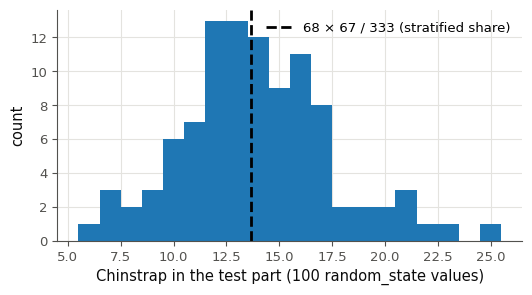

In [23]:
X_tr_11, X_te_11, y_tr_11, y_te_11 = sklearn_train_test_split(X_peng, species, test_size=0.2, random_state=42)
n_test_11a = len(X_te_11)
chinstrap_11b = int(np.sum(y_te_11 == "Chinstrap"))
y_te_strat_11 = sklearn_train_test_split(X_peng, species, test_size=0.2, random_state=42, stratify=species)[3]
chinstrap_11c = int(np.sum(y_te_strat_11 == "Chinstrap"))
y_te_ordered_11 = sklearn_train_test_split(X_peng, species, test_size=0.2, shuffle=False)[3]
n_species_11d = len(np.unique(y_te_ordered_11))
counts_11 = [int(np.sum(sklearn_train_test_split(X_peng, species, test_size=0.2, random_state=seed)[3] == "Chinstrap"))
             for seed in range(100)]
range_11e = [min(counts_11), max(counts_11)]
print("a)", n_test_11a, "· b)", chinstrap_11b, "· c)", chinstrap_11c, "· d)", n_species_11d, "· e)", range_11e)
print("species of the test part with shuffle=False:", np.unique(y_te_ordered_11).tolist())
plt.figure(figsize=(6, 3))
plt.hist(counts_11, bins=np.arange(min(counts_11), max(counts_11) + 2) - 0.5, color="tab:blue")
plt.axvline(68 * 67 / 333, color="black", ls="--", label="68 × 67 / 333 (stratified share)")
plt.xlabel("Chinstrap in the test part (100 random_state values)")
plt.ylabel("count")
plt.legend()
plt.show()

In [24]:
wb.record("8.11a", n_test_11a, mistakes={"0,2 × 333 = 66,6 : scikit-learn arrondit la taille du test vers le haut": 66,
                                       "c'est la taille de l'entraînement": 266})
wb.record("8.11b", chinstrap_11b, mistakes={"c'est le nombre obtenu avec stratify : ici, sans stratify": chinstrap_11c})
wb.record("8.11c", chinstrap_11c, mistakes={"c'est le nombre obtenu sans stratify : ajoute stratify=species": chinstrap_11b})
wb.record("8.11d", n_species_11d, mistakes={"regarde les espèces des 67 dernières lignes : le fichier est trié par espèce": 3})
wb.record("8.11e", range_11e)

WB_ANSWER {"hash": "fa10147816d54e7d446ce77674ecbc7f77a8e64dd3036851a317390644688ca0", "id": "8.11a", "kind": "int", "magnitude": 1, "mistakes": {"a5aaf32b7cefffa2ce92522300d5cb3146616d617fb1cdc486ce079da6eb90cf": "0,2 × 333 = 66,6 : scikit-learn arrondit la taille du test vers le haut", "f45230f1573f0aec36b5134a3952c8856eaa761f270fe078d5cc488bcf5e656e": "c'est la taille de l'entraînement"}, "sign": 1}
📝 Ex 8.11a : réponse enregistrée (int).
WB_ANSWER {"hash": "631ad7b6f04f2ab30891165f94b154fbd4fc912e7c4e88fe142cab29c3fd5bcb", "id": "8.11b", "kind": "int", "magnitude": 1, "mistakes": {"ceb054cc94e3495d44d8a3de9ad65a73d8d77ad1a7dbcfcc8d8741014ee5bc2f": "c'est le nombre obtenu avec stratify : ici, sans stratify"}, "sign": 1}
📝 Ex 8.11b : réponse enregistrée (int).
WB_ANSWER {"hash": "c6b6d04774ab86a62eb4954a2f39a7c6bb1651568b19b6c46d237e1b2a7d81da", "id": "8.11c", "kind": "int", "magnitude": 1, "mistakes": {"2ba0ac78b68e6a49c00516fc05f07133b4b0a47d60acccadd64ae52e33e26a85": "c'est le nom

💡 La stratification place 14 Chinstrap dans le test : leur part exacte vaut $68 \times 67 / 333 \approx 13{,}7$, arrondie par la règle du plus fort reste (scikit-learn répartit d'abord l'entraînement, ce qui revient ici au même). Sans stratification, la graine 42 en donne 18, et les graines 0 à 99 donnent de 6 à 25 Chinstrap : un test de 67 manchots peut contenir deux fois trop ou deux fois trop peu d'une classe rare. Avec `shuffle=False`, les 67 dernières lignes sont toutes des Chinstrap : le modèle s'entraînerait sur une seule Chinstrap et serait testé sur elles seules.

### Ex 8.12 — Le modèle qui apprend par cœur : accuracy d'entraînement et de test 🔮 ★ ⏱️ 15 min
**Objectif :** prévoir l'accuracy d'un modèle qui retient tous ses exemples, sur l'entraînement et sur le test, avec de vrais labels et avec des labels tirés au hasard.  
**Prérequis :** ch. 1 (1.14, le mémoriseur) · ch. 7 (plus proche voisin) · fiche §8.2.1 · **Fil rouge :** Penguins · **Parcours :** C

Au ch. 1 (1.14), le mémoriseur ne savait répondre qu'aux manchots qu'il avait déjà vus. `OneNN` apprend aussi « par cœur » (son `fit` range tous les exemples), mais il répond à tout : il copie le label du manchot d'entraînement **le plus proche** (ch. 7). On l'entraîne sur les 233 manchots du découpage du ch. 1, avec leurs quatre mesures standardisées (`Z_12`, moyenne et écart-type des 233 manchots d'entraînement), puis on mesure son accuracy sur ces mêmes 233 manchots et sur les 100 du test. Deux expériences :
- avec les **vraies espèces** ;
- avec des espèces **mélangées au hasard** entre les manchots (`shuffled_12`) : le label n'a plus aucun lien avec les mesures.

Prédis, **avant** d'exécuter quoi que ce soit, l'intervalle de chacune des quatre accuracies : `"A"` exactement 1 ; `"B"` entre 0,9 et 1, sans atteindre 1 ; `"C"` entre 0,5 et 0,9 ; `"D"` moins de 0,5.
a) entraînement, vraies espèces ;
b) test, vraies espèces ;
c) entraînement, espèces mélangées ;
d) test, espèces mélangées.

Puis exécute l'expérience. Dans tes notes : pourquoi c) vaut-il ce qu'il vaut ? Que dit l'expérience du score d'entraînement d'un modèle très flexible ? À quoi correspond la valeur de d) (le niveau du hasard affiché par l'expérience) ?

In [25]:
Z_12 = (X_peng - X_peng[TRAIN_CH1].mean(axis=0)) / X_peng[TRAIN_CH1].std(axis=0)   # standardised with the training rows
shuffled_12 = np.random.default_rng(812).permutation(species)   # the species, shuffled at random among the penguins
print("the first five penguins, true and shuffled species:", species[:5].tolist(), shuffled_12[:5].tolist())

the first five penguins, true and shuffled species: ['Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie'] ['Gentoo', 'Adelie', 'Adelie', 'Chinstrap', 'Gentoo']


In [26]:
prediction_12a, prediction_12b, prediction_12c, prediction_12d = "A", "B", "A", "D"   # the answers, for the record

In [27]:
wb.record("8.12a", prediction_12a, mistakes={"chaque manchot d'entraînement est dans la mémoire du modèle : quel est son plus proche voisin ?": "B"})
wb.record("8.12b", prediction_12b, mistakes={"sur des manchots nouveaux, le plus proche voisin peut se tromper": "A",
                                             "les espèces se séparent bien avec les quatre mesures (ch. 1 et 7)": "C"})
wb.record("8.12c", prediction_12c, mistakes={"le label d'un manchot d'entraînement, même tiré au hasard, est dans la mémoire du modèle": "D",
                                             "quel est le plus proche voisin d'un manchot d'entraînement ?": "B"})
wb.record("8.12d", prediction_12d, mistakes={"le label d'un manchot de test n'a plus aucun lien avec ses mesures : que vaut copier celui d'un voisin ?": "C"})

WB_ANSWER {"hash": "9a6e67bc35f33bd5ee1465e7aeab75b49f7a7bdbbbc8e192927e7db1a3f649c6", "id": "8.12a", "kind": "str", "mistakes": {"3bc6139ea46441be9a0cc4beb4b8a150ffcf930c1c2ac1b7bb5b4a71afacbfe5": "chaque manchot d'entraînement est dans la mémoire du modèle : quel est son plus proche voisin ?"}}
📝 Ex 8.12a : réponse enregistrée (str).
WB_ANSWER {"hash": "f806fdc639bdf4d58a2506aa1edfac5a54c4b40685c714dfc319bbbe67405c5f", "id": "8.12b", "kind": "str", "mistakes": {"3c11e0cc1a57dd0f4b4699fcfb30bf927cb6c69a8584ae31658aceb7c955d63b": "sur des manchots nouveaux, le plus proche voisin peut se tromper", "8f339a0214e05da884336c2935692830f21031909617aaf02bcbc10775292459": "les espèces se séparent bien avec les quatre mesures (ch. 1 et 7)"}}
📝 Ex 8.12b : réponse enregistrée (str).
WB_ANSWER {"hash": "201a93688ef9c4a3efa42b16323a6702da8c1de3c00f83c3487b7e4bcc189174", "id": "8.12c", "kind": "str", "mistakes": {"02d3def49aecaf3f433be5c446a8c612618ac6ca517148e3982daa8f82e5f00c": "quel est le plus pr

true species      train: accuracy 1.00
true species      test : accuracy 0.99
shuffled species  train: accuracy 1.00
shuffled species  test : accuracy 0.36
chance level of the shuffled labels (sum of the squared class shares): 0.37


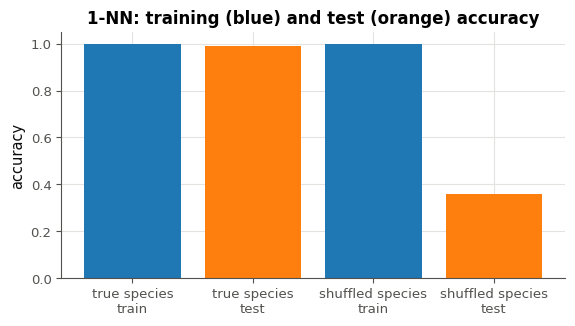

In [28]:
if any(answer is ... or answer is None for answer in [prediction_12a, prediction_12b, prediction_12c, prediction_12d]):
    print("⏳ Ex 8.12 : écris d'abord tes quatre prédictions, puis relance cette cellule.")
else:
    accuracies_12 = {}
    for name_12, labels_12 in [("true species", species), ("shuffled species", shuffled_12)]:
        model_12 = OneNN().fit(Z_12[TRAIN_CH1], labels_12[TRAIN_CH1])
        accuracies_12[(name_12, "train")] = model_12.score(Z_12[TRAIN_CH1], labels_12[TRAIN_CH1])
        accuracies_12[(name_12, "test")] = model_12.score(Z_12[TEST_CH1], labels_12[TEST_CH1])
    for (name_12, part_12), value_12 in accuracies_12.items():
        print(f"{name_12:17s} {part_12:5s}: accuracy {value_12:.2f}")
    shares_12 = np.unique(shuffled_12[TRAIN_CH1], return_counts=True)[1] / len(TRAIN_CH1)
    print(f"chance level of the shuffled labels (sum of the squared class shares): {np.sum(shares_12 ** 2):.2f}")
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    names_12 = [f"{name}\n{part}" for name, part in accuracies_12]
    ax.bar(names_12, list(accuracies_12.values()), color=["tab:blue", "tab:orange", "tab:blue", "tab:orange"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("accuracy")
    ax.set_title("1-NN: training (blue) and test (orange) accuracy")
    plt.show()

💡 Sur l'entraînement, le plus proche voisin d'un manchot est lui-même (distance nulle, et aucun manchot n'a exactement les mêmes quatre mesures qu'un autre) : l'accuracy vaut **exactement 1**, avec les vraies espèces comme avec des espèces tirées au hasard. Sur le test, les vraies espèces donnent 0,99, les espèces mélangées 0,36, soit le niveau du hasard (environ $\sum_k p_k^2 \approx 0{,}37$ : la probabilité que deux manchots tirés au hasard aient le même label). Le score d'entraînement d'un modèle qui peut tout retenir ne distingue donc pas un modèle qui a appris d'un modèle qui n'a rien appris : seul le test les sépare. C. Zhang et ses collègues ont montré en 2017 que de grands réseaux de neurones retiennent eux aussi des labels tirés au hasard.

### Ex 8.13 — train_test_split from scratch 🔨 ★★ ⏱️ 30 min
**Objectif :** écrire un découpage hold-out complet : tailles, mélange, stratification, alignement de plusieurs tableaux.  
**Prérequis :** Ex 8.11 · 0A (`rng.permutation`, indexation par un tableau d'indices) · fiche §8.3 · **Fil rouge :** Penguins · **mylearn :** `model_selection.py` · **Parcours :** R, M, C

> **Mode d'emploi mylearn** (comme aux chapitres précédents) : ouvre `mon_travail/mylearn/model_selection.py` (créé par `python tools/start_chapter.py 8`), lis la docstring de chaque fonction, remplace les `raise NotImplementedError(...)` par ton code et **enregistre**. NumPy, `math`, `copy` et `warnings` sont permis ; scikit-learn non : ses fonctions (`train_test_split`, `KFold`, `StratifiedKFold`, `cross_val_score`, `clone`) sont les **oracles** des tests. La cellule de vérification recharge ta librairie, montre quelques résultats, puis lance les tests de ta fonction ; `python -m pytest tests/test_ch08_model_selection.py -q` les lance tous dans un terminal.

Écris `train_test_split(*arrays, test_size=0.25, shuffle=True, stratify=None, rng=None)` (lis sa docstring) :
- convertis chaque tableau avec `np.asarray` ; lève une `ValueError` s'il n'y a aucun tableau ou si leurs nombres de lignes diffèrent ;
- la taille du test : un `float` de $]0, 1[$ donne $n_{\text{test}} = \lceil t \cdot n \rceil$ (`math.ceil(test_size * n)`), un `int` donne directement $n_{\text{test}}$ ; lève une `ValueError` si `test_size` est hors de ces bornes ou si l'une des deux parties serait vide ;
- choisis **une seule fois** les indices du test et ceux de l'entraînement, puis indexe **tous** les tableaux avec ces mêmes indices : c'est ce qui garde `X` et `y` alignés. Le résultat : `[a1_train, a1_test, a2_train, a2_test, ...]` ;
- `shuffle=False` : le test est formé des **dernières** lignes, dans leur ordre ; `shuffle=True` : tire les indices au hasard avec `rng` (`np.random.default_rng()` si `rng` vaut `None`), par exemple avec `rng.permutation(n)` ;
- `stratify=y` : chaque classe reçoit dans le test la partie entière de sa part exacte $n_c \cdot n_{\text{test}} / n$, et les exemples qui manquent vont aux classes dont la partie décimale est la plus grande (règle du plus fort reste, fiche §8.3) ; tire ensuite au hasard, avec `rng`, les lignes de chaque classe. Lève une `ValueError` avec `shuffle=False`, ou si une classe n'a qu'un seul membre.

Ne modifie jamais les tableaux reçus (mélange des indices, pas des données). La vérification essaie l'exemple de la docstring, puis un découpage stratifié des manchots, et lance les tests.

Dans tes notes : pourquoi faut-il tirer les indices **une seule fois** pour tous les tableaux ? Pourquoi les tests comparent-ils la **taille** de ton test à celle de scikit-learn, mais pas les manchots choisis ?

In [29]:
parts_13 = mylearn.model_selection.train_test_split(X_peng, species, test_size=0.2, stratify=species,
                                                    rng=np.random.default_rng(813))
X_tr_13, X_te_13, y_tr_13, y_te_13 = parts_13
print("stratified test part of the penguins:", len(X_te_13), "penguins,",
      {name: int(np.sum(y_te_13 == name)) for name in ("Adelie", "Chinstrap", "Gentoo")})
run_mylearn_tests(impl="ref", keyword="test_train_test_split_")

stratified test part of the penguins: 67 penguins, {'Adelie': 29, 'Chinstrap': 14, 'Gentoo': 24}


pytest: 43 passed, 61 deselected in 1.92s


💡 Dans la référence (`solutions/mylearn_ref/model_selection.py`, à lire **après** avoir réussi les tests), une fonction auxiliaire calcule $n_{\text{test}}$ et ses contrôles ; avec `stratify`, les quotas par classe viennent du plus fort reste, puis `rng.permutation` tire les lignes de chaque classe ; enfin, une seule paire d'indices sert à indexer tous les tableaux. Les tests ne comparent pas les manchots choisis à ceux de scikit-learn : deux générateurs différents tirent d'autres lignes, et les deux découpages sont justes. Ils vérifient les **propriétés** (tailles, parties disjointes, alignement, même graine = même découpage) et les effectifs par classe.

### Ex 8.14 — Les indices de la k-fold : kfold_indices 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire les indices (entraînement, validation) des k tours d'une validation croisée.  
**Prérequis :** Ex 8.1 · Ex 8.13 · fiche §8.5.1 · **mylearn :** `model_selection.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/model_selection.py`, mêmes règles qu'en 8.13 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `kfold_indices(n_samples, n_splits=5, shuffle=False, rng=None)` (lis sa docstring) :
- lève une `ValueError` si `n_splits < 2` ou si `n_splits > n_samples` ;
- les indices `0, 1, …, n_samples - 1` (mélangés **une fois** avec `rng.permutation` si `shuffle=True`) sont coupés en `n_splits` folds **consécutifs** ; les `n_samples % n_splits` premiers folds ont un exemple de plus (fiche §8.5.1) ;
- renvoie une **liste** de `n_splits` paires `(train_idx, val_idx)` : le fold `i` est la validation du tour `i`, tous les autres indices son entraînement. Sans mélange, les indices de chaque partie sont en ordre croissant, comme ceux de `KFold` de scikit-learn, l'oracle des tests.

La vérification affiche l'exemple de la docstring, compare tes folds à ceux de `KFold` sur les 333 manchots, puis lance les tests.

Dans tes notes : que se passe-t-il si l'on applique `kfold_indices(333, 5)` **sans mélange** aux manchots, triés par espèce ? Regarde les espèces de chaque fold de validation.

In [30]:
for i_14, (train_14, val_14) in enumerate(mylearn.model_selection.kfold_indices(len(species), n_splits=5)):
    names_14, counts_14 = np.unique(species[val_14], return_counts=True)
    print(f"fold {i_14 + 1}: {len(val_14)} penguins,", dict(zip(names_14.tolist(), counts_14.tolist())))
run_mylearn_tests(impl="ref", keyword="test_kfold_indices_")

fold 1: 67 penguins, {'Adelie': 67}
fold 2: 67 penguins, {'Adelie': 67}
fold 3: 67 penguins, {'Adelie': 12, 'Gentoo': 55}
fold 4: 66 penguins, {'Chinstrap': 2, 'Gentoo': 64}
fold 5: 66 penguins, {'Chinstrap': 66}


pytest: 21 passed, 83 deselected in 1.13s


💡 333 = 5 × 66 + 3 : trois folds de 67 et deux de 66. Sans mélange, sur les manchots triés par espèce, les deux premiers folds ne contiennent que des Adélie, le troisième 12 Adélie et 55 Gentoo, le quatrième 64 Gentoo et 2 Chinstrap, le dernier 66 Chinstrap : au dernier tour, le modèle s'entraîne avec seulement deux Chinstrap et doit reconnaître toutes les autres. Il faut mélanger (`shuffle=True`) ou stratifier (8.21).

### Ex 8.15 — Reproduire la figure 8.13 : la rotation des folds 🎨 ★★ ⏱️ 20 min
**Objectif :** dessiner la rotation des folds d'une validation croisée à partir des indices, et la comparer avec un mélange et une stratification.  
**Prérequis :** Ex 8.14 · livre §8.5.1 (figure 8.13) · **Parcours :** C

La figure 8.13 du livre montre les 5 tours d'une validation croisée à 5 folds : à chaque tour, un fold sert de validation et les autres d'entraînement. Reproduis-la à partir de **tes** indices.

Écris :
- `fold_matrix_15(splits, n)` : un tableau d'entiers de forme `(len(splits), n)`, qui vaut 1 en ligne `i`, colonne `j` quand l'échantillon `j` est dans le fold de validation du tour `i`, et 0 sinon ;
- `draw_folds_15(ax, splits, n, title)` : le dessin de cette matrice sur `ax`, un tour par ligne, deux couleurs (par exemple `ax.imshow(..., cmap=ListedColormap(["tab:blue", "tab:orange"]), aspect="auto")`, avec `from matplotlib.colors import ListedColormap`), des graduations lisibles et le titre.

La vérification contrôle ta matrice pour 20 échantillons et 5 folds, puis dessine trois versions : la figure du livre, la même après un mélange, et une validation croisée **stratifiée** à 4 folds sur 12 échantillons d'une classe et 8 d'une autre (elle utilise ta fonction de 8.21 si tu l'as déjà écrite, et affiche ⏳ sinon : reviens alors ici après 8.21).

Dans tes notes : combien de 1 dans chaque colonne de la matrice, et pourquoi ? Dans la version stratifiée, combien d'échantillons de chaque classe chaque fold reçoit-il ?

In [31]:
# 20 samples and 5 folds, as in figure 8.13 of the book; then shuffled; then stratified on 20 labels
LABELS_15 = np.array([0] * 12 + [1] * 8)                  # 12 samples of class 0, then 8 of class 1

✅ Ex 8.15 : la matrice de la rotation : chaque échantillon passe une fois en validation, les folds se suivent.


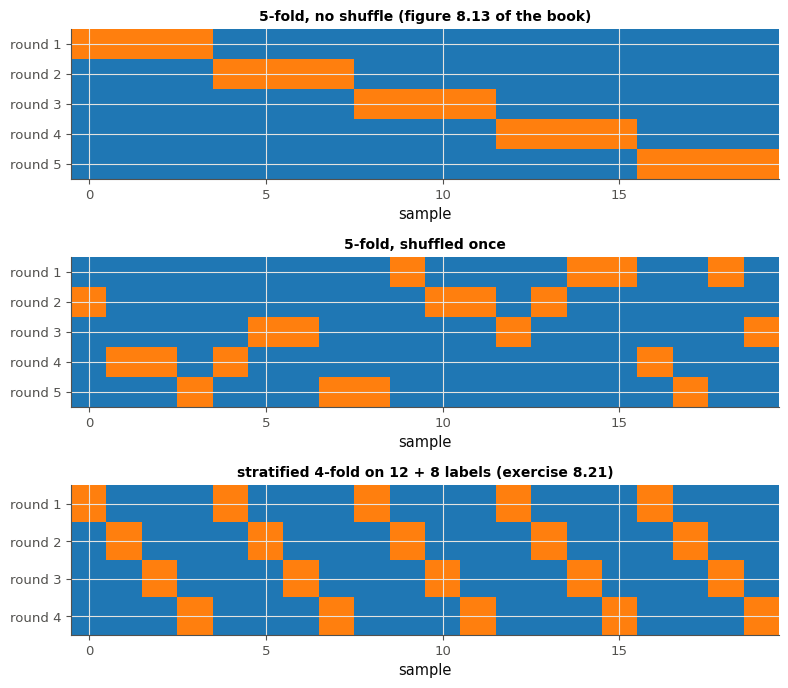

In [32]:
def fold_matrix_15(splits, n):
    """Matrix of shape (len(splits), n): 1 where sample j is in the validation fold of split i, 0 elsewhere."""
    matrix = np.zeros((len(splits), n), dtype=int)
    for i, (_, val_idx) in enumerate(splits):
        matrix[i, val_idx] = 1
    return matrix


def draw_folds_15(ax, splits, n, title):
    """Draw fold_matrix_15(splits, n) on ax: one row per split, validation and training in two colours."""
    from matplotlib.colors import ListedColormap
    ax.imshow(fold_matrix_15(splits, n), cmap=ListedColormap(["tab:blue", "tab:orange"]), aspect="auto", vmin=0, vmax=1)
    ax.set_yticks(range(len(splits)), [f"round {i + 1}" for i in range(len(splits))])
    ax.set_xticks(range(0, n, 5))
    ax.set_xlabel("sample")
    ax.set_title(title, fontsize=10)


if True:
    splits_15 = mylearn.model_selection.kfold_indices(20, n_splits=5)
    good_15 = split_pairs("8.15", "kfold_indices (8.14)", splits_15, 5)
    matrix_15 = fold_matrix_15(splits_15, 20) if good_15 else None
    if good_15 and returned("8.15", "fold_matrix_15", matrix_15):
        matrix_15 = np.asarray(matrix_15)
        expected_15 = np.kron(np.eye(5, dtype=int), np.ones((1, 4), dtype=int))     # fold i = samples 4i to 4i + 3
        verdict("8.15", matrix_15.shape == (5, 20) and np.array_equal(matrix_15, expected_15),
                "la matrice de la rotation : chaque échantillon passe une fois en validation, les folds se suivent.",
                f"attendu une matrice (5, 20) de 0 et de 1, avec des 1 aux échantillons du fold de validation de "
                f"chaque tour ; reçu une forme {matrix_15.shape}.")
        try:
            stratified_15 = mylearn.model_selection.stratified_kfold_indices(LABELS_15, 4)
        except NotImplementedError:
            stratified_15 = None
            print("⏳ la troisième figure, stratifiée, s'affichera quand tu auras écrit stratified_kfold_indices (8.21).")
        if stratified_15 is not None and not split_pairs("8.15", "stratified_kfold_indices (8.21)", stratified_15, 4):
            stratified_15 = None
        fig, axes = plt.subplots(2 if stratified_15 is None else 3, 1, figsize=(8, 4.8 if stratified_15 is None else 7))
        try:
            draw_folds_15(axes[0], splits_15, 20, "5-fold, no shuffle (figure 8.13 of the book)")
        except NotImplementedError:
            plt.close(fig)                                  # no empty figure before draw_folds_15 is written
            raise
        draw_folds_15(axes[1], mylearn.model_selection.kfold_indices(20, 5, shuffle=True, rng=np.random.default_rng(815)),
                      20, "5-fold, shuffled once")
        if stratified_15 is not None:
            draw_folds_15(axes[2], stratified_15, 20, "stratified 4-fold on 12 + 8 labels (exercise 8.21)")
        fig.tight_layout()
        plt.show()

💡 Chaque colonne contient exactement un 1 : chaque échantillon sert une fois, et une seule, de validation. Sans mélange, les folds sont des blocs consécutifs, et la matrice est une suite de blocs le long de la diagonale ; après un mélange, les 1 d'un tour sont dispersés. Dans la version stratifiée, chaque fold de validation reçoit 3 échantillons de la classe 0 et 2 de la classe 1 (12 et 8 répartis sur 4 folds).

## Partie B · Choisir un hyperparamètre sur un jeu de validation

Fil rouge : le prix des logements de Californie (recensement de 1990), qui remplace dans le workbook le dataset de Boston retiré de scikit-learn. On garde les districts dont le revenu médian est entre 1 et 8 (dizaines de milliers de dollars) et dont la valeur médiane n'est pas plafonnée à 5 (centaines de milliers de dollars), puis on en tire 400 au hasard : `X_cal` (le revenu, un tableau de forme (400, 1)) et `y_cal` (la valeur des logements). L'hyperparamètre à régler est le **degré** d'un polynôme ; le ch. 9 y reviendra en détail.

In [33]:
california = wb.datasets.load_california()       # 20 640 districts of California (1990 census)
keep_cal = (california["MedInc"] >= 1) & (california["MedInc"] <= 8) & (california["MedHouseVal"] < 5)
income_all = california.loc[keep_cal, "MedInc"].to_numpy()       # median income of a district (tens of thousands of $)
value_all = california.loc[keep_cal, "MedHouseVal"].to_numpy()   # median house value (hundreds of thousands of $)
rows_cal = np.random.default_rng(937).choice(len(income_all), size=400, replace=False)   # 400 districts, in random order
X_cal = income_all[rows_cal].reshape(-1, 1)        # one feature, but a 2-D X of shape (400, 1), as in scikit-learn
y_cal = value_all[rows_cal]
print(f"{len(income_all)} districts kept, {len(X_cal)} drawn at random: income from {X_cal.min():.2f} to "
      f"{X_cal.max():.2f}, house value from {y_cal.min():.2f} to {y_cal.max():.2f}")

19249 districts kept, 400 drawn at random: income from 1.18 to 7.98, house value from 0.38 to 4.83


### Ex 8.16 — Un estimateur maison à la scikit-learn : PolyFit(degree) 🔨 ★★ ⏱️ 25 min
**Objectif :** écrire un régresseur qui respecte les conventions de scikit-learn : hyperparamètres rangés par __init__, fit qui renvoie self, predict, et score qui renvoie le R².  
**Prérequis :** 0A (classes) · 0B (polynômes) · fiche §8.4 (encadré 🧮 sur le $R^2$) · **Fil rouge :** California · **Parcours :** R, C

Écris, dans la cellule ci-dessous, la classe `PolyFit` : une régression polynomiale de `y` sur la seule feature `X[:, 0]`.
- `__init__(self, degree=1)` : range l'hyperparamètre, **et rien d'autre** (`self.degree = degree` : ni calcul, ni vérification). C'est la convention qui permettra à `clone` (8.22) de fabriquer un `PolyFit` neuf avec le même degré ;
- `fit(self, X, y)` : `x = np.asarray(X, dtype=float)[:, 0]`, puis `self.coef_ = np.polyfit(x, y, self.degree)` (les moindres carrés, du plus haut degré au plus bas) ; renvoie `self` ;
- `predict(self, X)` : `np.polyval(self.coef_, x)`, une prédiction par ligne de `X` ;
- `score(self, X, y)` : le $R^2$ des prédictions (encadré 🧮 de la fiche, §8.4), un `float`.

La vérification :
a) entraîne `PolyFit(degree=2)` sur quatre points d'un polynôme de degré 2 et vérifie la prédiction en $x = 4$ ;
b) entraîne `PolyFit(degree=2)` sur les 300 premiers districts de `X_cal` et vérifie son $R^2$ sur les 100 autres ;
puis elle contrôle les conventions (`vars(PolyFit(degree=3))`, `fit` qui renvoie le modèle), compare ton $R^2$ à celui de scikit-learn (`PolynomialFeatures` puis `LinearRegression`) et dessine trois polynômes.

Dans tes notes : que fait le polynôme de degré 8 aux bords des données ? Pourquoi `__init__` ne doit-il pas calculer quoi que ce soit ?

8.16a: 20.999999999999996
✅ Ex 8.16 : __init__ ne fait que ranger degree : clone (8.22) saura copier PolyFit.
✅ Ex 8.16 : fit renvoie le modèle lui-même.
8.16b: 0.41795060335382817
✅ Ex 8.16 : le même R² que PolynomialFeatures + LinearRegression de scikit-learn.


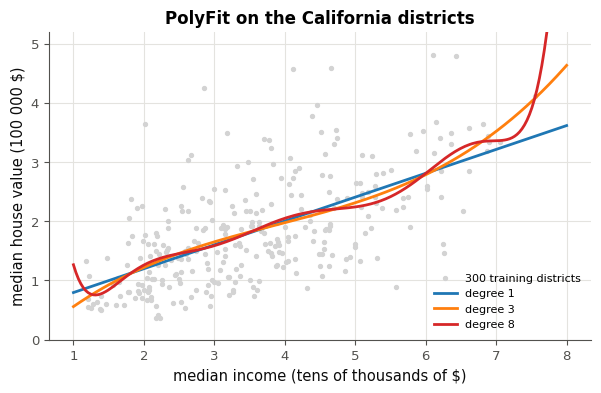

In [34]:
class PolyFit:
    """Polynomial regression of y on the single feature X[:, 0], fitted by least squares (np.polyfit)."""

    def __init__(self, degree=1):
        self.degree = degree                        # only store the hyperparameter (convention used by clone)

    def fit(self, X, y):
        x = np.asarray(X, dtype=float)[:, 0]
        self.coef_ = np.polyfit(x, np.asarray(y, dtype=float), self.degree)
        return self

    def predict(self, X):
        return np.polyval(self.coef_, np.asarray(X, dtype=float)[:, 0])

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        residual = np.sum((y - self.predict(X)) ** 2)
        total = np.sum((y - y.mean()) ** 2)
        return float(1 - residual / total)


if True:
    toy_16 = fitted(PolyFit(degree=2), np.array([[0.0], [1.0], [2.0], [3.0]]), np.array([1.0, 3.0, 7.0, 13.0]))
    pred_16 = toy_16.predict(np.array([[4.0]]))
    if returned("8.16", "predict", pred_16):
        pred_16 = np.asarray(pred_16, dtype=float).ravel()
        if pred_16.shape != (1,):
            print(f"❌ Ex 8.16 : predict doit renvoyer une valeur par ligne de X (ici une seule), reçu une forme {pred_16.shape}.")
        else:
            print_answer("8.16a", float(pred_16[0]), computed=True)
    params_16 = vars(PolyFit(degree=3))
    verdict("8.16", params_16 == {"degree": 3},
            "__init__ ne fait que ranger degree : clone (8.22) saura copier PolyFit.",
            f"vars(PolyFit(degree=3)) vaut {params_16} : __init__ doit seulement écrire self.degree = degree.")
    one_16 = PolyFit(degree=1)
    verdict("8.16", one_16.fit(X_cal, y_cal) is one_16, "fit renvoie le modèle lui-même.",
            "fit doit renvoyer le modèle lui-même (return self).")
    model_16 = fitted(PolyFit(degree=2), X_cal[:300], y_cal[:300])
    many_16 = model_16.predict(X_cal[300:305])
    if returned("8.16", "predict", many_16) and np.shape(many_16) != (5,):
        print(f"❌ Ex 8.16 : predict doit renvoyer une prédiction par ligne de X : forme (5,) attendue pour 5 "
              f"districts, reçu {np.shape(many_16)}.")
    r2_16 = model_16.score(X_cal[300:], y_cal[300:])
    if returned("8.16", "score", r2_16) and not isinstance(r2_16, (int, float)):
        print(f"❌ Ex 8.16 : score doit renvoyer un nombre (le R²), reçu un objet de type {type(r2_16).__name__}.")
    elif r2_16 is not None:
        print_answer("8.16b", r2_16, computed=True)
        oracle_16 = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_cal[:300], y_cal[:300])
        verdict("8.16", abs(float(r2_16) - oracle_16.score(X_cal[300:], y_cal[300:])) < 1e-8,
                "le même R² que PolynomialFeatures + LinearRegression de scikit-learn.",
                "ton R² diffère de celui de scikit-learn : relis la formule de l'encadré 🧮 de la fiche (§8.4).")
        if np.shape(many_16) == (5,):                     # draw only with a predict of the right shape
            grid_16 = np.linspace(1, 8, 200).reshape(-1, 1)
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.scatter(X_cal[:300, 0], y_cal[:300], s=8, color="lightgray", label="300 training districts")
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")              # np.polyfit warns that degree 8 is poorly conditioned
                for degree_16, colour_16 in [(1, "tab:blue"), (3, "tab:orange"), (8, "tab:red")]:
                    curve_16 = fitted(PolyFit(degree=degree_16), X_cal[:300], y_cal[:300]).predict(grid_16)
                    ax.plot(grid_16[:, 0], curve_16, color=colour_16, label=f"degree {degree_16}")
            ax.set(xlabel="median income (tens of thousands of $)", ylabel="median house value (100 000 $)",
                   ylim=(0, 5.2), title="PolyFit on the California districts")
            ax.legend(fontsize=8)
            plt.show()

In [35]:
wb.record("8.16a", float(toy_16.predict(np.array([[4.0]]))[0]), decimals=4)
wb.record("8.16b", r2_16, decimals=4, mistakes={"c'est le R² sur les 300 districts d'entraînement : la question demande les 100 autres": model_16.score(X_cal[:300], y_cal[:300])})

WB_ANSWER {"decimals": 4, "hash": "c23b470641e5eaba75339d1124717b33991bb49c337f47de5d7e09540f209f2c", "hash_coarse": "69f080d812ee5fe6e37cfcf1bddb4f427eff6f0febe3e78443398886d27a6fb4", "id": "8.16a", "kind": "float", "magnitude": 1, "sign": 1}
📝 Ex 8.16a : réponse enregistrée (float, 4 décimale(s)).
ℹ️ Ex 8.16b : valeur à une limite d'arrondi ; les deux arrondis sont acceptés.
WB_ANSWER {"alt_hashes": ["b95de417e22b715bee51edce44e4ea0117c9a2b28da5b6fe0c324013a00a7bee"], "decimals": 4, "hash": "0762b190cbd26cf75415a75def960b0d09fcbfd9009a3a57accb24edba54955e", "hash_coarse": "d5229757495e2dc34381dfab3ae4fbccb37394c72e6d0683ef7d647ed3c62d6c", "id": "8.16b", "kind": "float", "magnitude": -1, "mistakes": {"fd7c3e1434d783a9e709f21a267a4b66e8c10266b6f8eafd96200425f495fb7e": "c'est le R² sur les 300 districts d'entraînement : la question demande les 100 autres"}, "sign": 1}
📝 Ex 8.16b : réponse enregistrée (float, 4 décimale(s)).


💡 Les quatre points vérifient $y = x^2 + x + 1$ : le polynôme appris passe par eux, et prédit 21 en $x = 4$. Sur les districts, le degré 2 obtient un $R^2$ de 0,418 sur les 100 districts qu'il n'a pas vus. Le degré 8 ondule aux bords, là où les districts sont rares : un polynôme de haut degré extrapole très mal. Si `__init__` calculait quelque chose (une normalisation, une vérification qui modifie le degré), `clone` reconstruirait un objet différent de l'original ; et un `__init__` qui entraîne déjà le modèle n'aurait plus rien à faire dans `fit`.

### Ex 8.17 — Validation ou test : lequel sera le plus optimiste ? 🔮 ★★ ⏱️ 15 min
**Objectif :** prévoir, sur des centaines de répétitions, l'écart entre le score de validation du réglage retenu et son score de test.  
**Prérequis :** Ex 8.16 · ∂ 8.6 · fiche §8.4 · **Fil rouge :** California · **Parcours :** C

L'expérience répète 300 fois la même procédure : tirer 360 districts au hasard ; entraîner `PolyFit` de degré 1 à 12 sur 40 d'entre eux ; noter chaque degré sur 20 districts de validation ; garder le degré qui a le meilleur $R^2$ de validation ; noter **ce** degré sur 300 districts de test. Elle note aussi, à chaque répétition, le degré 1, choisi **d'avance**, sur les mêmes districts. Elle utilise **ta** classe `PolyFit` (8.16).

Prédis, **avant** d'exécuter l'expérience (`True` ou `False`) :
a) `chosen_17` : le $R^2$ de validation du degré retenu dépassera son $R^2$ de test dans **plus de la moitié** des 300 répétitions ;
b) `fixed_17` : pour le degré 1, choisi d'avance, la part des répétitions où le $R^2$ de validation dépasse le $R^2$ de test sera comprise **entre 40 % et 60 %** ;
c) `helps_17` : le $R^2$ de test **médian** du degré retenu sera plus haut que celui du degré 1.

Puis exécute l'expérience. Dans tes notes : explique a) et b) avec ∂ 8.6. Pourquoi choisir le degré sur 20 districts de validation peut-il donner, en test, un moins bon modèle que de fixer le degré 1 d'avance ? Que faudrait-il changer dans la procédure ?

In [36]:
def repeat_17(n_repeats=300):
    """For each repetition: 360 districts drawn at random, PolyFit of degree 1 to 12 trained on 40 of them, R² on 20
    validation districts and on 300 test districts. Returns, for each repetition, the validation and test R² of the
    degree chosen on the validation set, then those of degree 1 (fixed in advance)."""
    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")              # high degrees on 40 points: np.polyfit warns, as expected
        for repetition in range(n_repeats):
            drawn = np.random.default_rng(1700 + repetition).choice(len(income_all), size=360, replace=False)
            x, v = income_all[drawn].reshape(-1, 1), value_all[drawn]
            val_scores, test_scores = [], []
            for degree in range(1, 13):
                model = fitted(PolyFit(degree=degree), x[:40], v[:40])
                val_scores.append(model.score(x[40:60], v[40:60]))
                test_scores.append(model.score(x[60:], v[60:]))
            best = int(np.argmax(val_scores))
            rows.append((val_scores[best], test_scores[best], val_scores[0], test_scores[0]))
    return np.array(rows, dtype=float)

In [37]:
chosen_17, fixed_17, helps_17 = True, True, False   # the answers, for the record

In [38]:
wb.record("8.17a", chosen_17, mistakes={"le degré retenu a été choisi PARCE QUE son score de validation était le plus haut (∂ 8.6)": False})
wb.record("8.17b", fixed_17, mistakes={"un degré fixé d'avance n'a profité d'aucune sélection : sa validation et son test sont deux mesures honnêtes": False})
wb.record("8.17c", helps_17, mistakes={"sur 20 districts, le meilleur score de validation est surtout le plus chanceux : le degré retenu est-il vraiment meilleur ?": True})

WB_ANSWER {"hash": "cd2a87e532cd3645bb348f146bde16fa1e8b4e95a770b684f95868c9364fded7", "id": "8.17a", "kind": "bool", "mistakes": {"29ae63b820d7ebf639dcf5ab728eea3c788e529a634597454eba4cb6c59ada3a": "le degré retenu a été choisi PARCE QUE son score de validation était le plus haut (∂ 8.6)"}}
📝 Ex 8.17a : réponse enregistrée (bool).
WB_ANSWER {"hash": "7ec5287760cd89b476a4868a26678701e9c3a61f84c7aba9adb512674ba10bd9", "id": "8.17b", "kind": "bool", "mistakes": {"45f67cdc38f4ed4af283f92513974b1724be2f2cdb4d8d3909da330bc87bc634": "un degré fixé d'avance n'a profité d'aucune sélection : sa validation et son test sont deux mesures honnêtes"}}
📝 Ex 8.17b : réponse enregistrée (bool).
WB_ANSWER {"hash": "8ceef03f3616b74965b577fe29d0895a6b8bcf2d796daf5245a16f3210daa490", "id": "8.17c", "kind": "bool", "mistakes": {"fc88118ce8f163222c89cebf4e08c114af3a86cfd4fd149c4037d490e766a2a0": "sur 20 districts, le meilleur score de validation est surtout le plus chanceux : le degré retenu est-il vraiment 

validation R² above test R²: chosen degree 64% of the repetitions, degree 1 49%
medians: chosen degree, validation 0.385 and test 0.336; degree 1, validation 0.348 and test 0.368


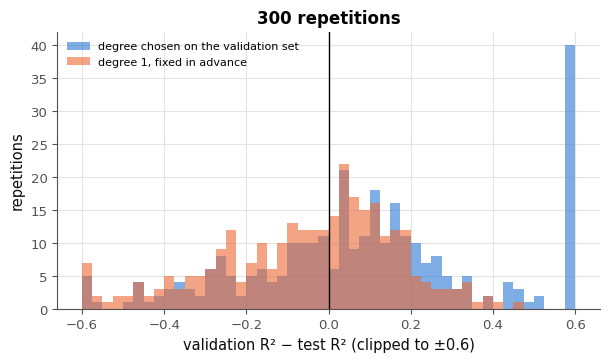

In [39]:
if any(answer is ... or answer is None for answer in [chosen_17, fixed_17, helps_17]):
    print("⏳ Ex 8.17 : écris d'abord tes trois prédictions, puis relance cette cellule.")
else:
    with wb.attempt("8.17"):
        trial_17 = fitted(PolyFit(degree=2), X_cal[:40], y_cal[:40]).score(X_cal[40:60], y_cal[40:60])
        if not isinstance(trial_17, (int, float)):        # np.float64 is a float
            print(f"❌ Ex 8.17 : l'expérience utilise ta classe PolyFit, dont score renvoie {type(trial_17).__name__} "
                  "au lieu d'un nombre : termine d'abord 8.16.")
        else:
            rows_17 = repeat_17()
            share_chosen_17 = np.mean(rows_17[:, 0] > rows_17[:, 1])
            share_fixed_17 = np.mean(rows_17[:, 2] > rows_17[:, 3])
            print(f"validation R² above test R²: chosen degree {share_chosen_17:.0%} of the repetitions, degree 1 {share_fixed_17:.0%}")
            print(f"medians: chosen degree, validation {np.median(rows_17[:, 0]):.3f} and test {np.median(rows_17[:, 1]):.3f}; "
                  f"degree 1, validation {np.median(rows_17[:, 2]):.3f} and test {np.median(rows_17[:, 3]):.3f}")
            fig, ax = plt.subplots(figsize=(7, 3.6))
            bins_17 = np.linspace(-0.6, 0.6, 49)
            ax.hist(np.clip(rows_17[:, 0] - rows_17[:, 1], -0.6, 0.6), bins=bins_17, alpha=0.6,
                    label="degree chosen on the validation set")
            ax.hist(np.clip(rows_17[:, 2] - rows_17[:, 3], -0.6, 0.6), bins=bins_17, alpha=0.6, label="degree 1, fixed in advance")
            ax.axvline(0, color="black", lw=1)
            ax.set(xlabel="validation R² − test R² (clipped to ±0.6)", ylabel="repetitions", title="300 repetitions")
            ax.legend(fontsize=8)
            plt.show()

💡 Le $R^2$ de validation du degré retenu dépasse son $R^2$ de test dans 64 % des répétitions, contre 49 % pour le degré 1 : choisir le maximum de douze scores bruités retient en partie le plus chanceux (∂ 8.6), et ce bonus disparaît sur le test. Pire, le $R^2$ de test médian du degré retenu (0,336) est **plus bas** que celui du degré 1 (0,368) : avec 20 districts de validation, la sélection choisit souvent un degré élevé qui a eu de la chance, et qui extrapole mal. Il faudrait plus de données de validation, une validation croisée, ou peu de candidats (un degré simple choisi d'avance). Sur **une** répétition, le test peut tout de même battre la validation : c'est une affaire de moyenne, pas une loi pour chaque découpage.

### Ex 8.18 — Boucle de sélection sur un jeu de validation : le degré du polynôme 🔨 ★★ ⏱️ 30 min
**Objectif :** programmer la boucle de la figure 8.9 : choisir un hyperparamètre sur la validation, réentraîner, tester une seule fois.  
**Prérequis :** Ex 8.16 · Ex 8.13 · fiche §8.4 · **Fil rouge :** California · **Parcours :** R, C

Écris `select_degree_18(X, y, degrees)`, la boucle de recherche d'hyperparamètres du livre (figure 8.9), avec **ta** fonction `mylearn.model_selection.train_test_split` (8.13) et **ta** classe `PolyFit` (8.16). Procédure imposée, pour que tout le monde trouve les mêmes nombres (les 400 districts sont déjà dans un ordre aléatoire, d'où `shuffle=False`) :
1. `X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)` : le test, mis de côté ;
2. `X_train, X_val, y_train, y_val = train_test_split(X_rest, y_rest, test_size=0.25, shuffle=False)` : soit 60 / 20 / 20 ;
3. pour chaque degré de `degrees`, un `PolyFit` **neuf** entraîné sur l'entraînement et noté ($R^2$) sur la validation ;
4. `best_degree` : le degré du meilleur $R^2$ de validation (le premier en cas d'égalité, comme `np.argmax`) ;
5. un `PolyFit(best_degree)` réentraîné sur entraînement + validation (`X_rest`, `y_rest`), puis noté **une fois** sur le test.

Renvoie `(val_scores, best_degree, test_score)`. La vérification lance ta fonction pour les degrés 1 à 8 et vérifie :
a) le degré retenu ;
b) le $R^2$ de test ;
puis elle trace les $R^2$ d'entraînement et de validation de chaque degré.

Dans tes notes : comment évolue le $R^2$ d'entraînement quand le degré augmente ? Et celui de validation ? Pourquoi réentraîner sur entraînement + validation avant le test ? Compare le $R^2$ de test au $R^2$ de validation du degré retenu : qu'en penses-tu, après 8.17 ?

8.18a: 3
8.18b: 0.4206180953711437


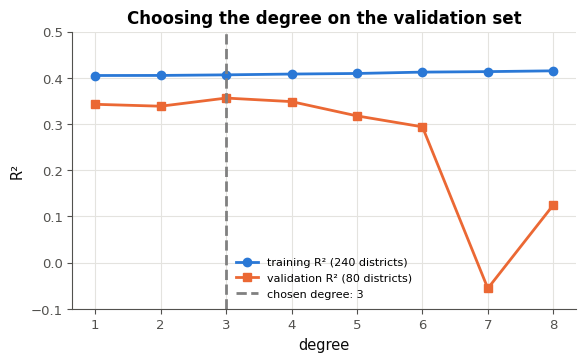

In [40]:
def select_degree_18(X, y, degrees):
    """Choose the degree of PolyFit on a validation set, then refit it and test it once.

    Returns (val_scores, best_degree, test_score): the validation R² of each degree (a list, in the order of
    `degrees`), the degree with the highest one (the first one on ties), and the test R² of PolyFit(best_degree)
    refitted on training + validation."""
    split = mylearn.model_selection.train_test_split
    X_rest, X_test, y_rest, y_test = split(X, y, test_size=0.2, shuffle=False)
    X_train, X_val, y_train, y_val = split(X_rest, y_rest, test_size=0.25, shuffle=False)
    val_scores = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                 # high degrees: np.polyfit warns, as expected
        for degree in degrees:
            val_scores.append(PolyFit(degree=degree).fit(X_train, y_train).score(X_val, y_val))
        best_degree = degrees[int(np.argmax(val_scores))]
        final = PolyFit(degree=best_degree).fit(X_rest, y_rest)          # training + validation
    return val_scores, best_degree, final.score(X_test, y_test)          # the test, once


if True:
    degrees_18 = list(range(1, 9))
    result_18 = select_degree_18(X_cal, y_cal, degrees_18)
    if returned("8.18", "select_degree_18", result_18):
        if not (isinstance(result_18, (tuple, list)) and len(result_18) == 3):
            print("❌ Ex 8.18 : select_degree_18 doit renvoyer un triplet (val_scores, best_degree, test_score).")
        else:
            val_18, best_18, test_18 = result_18
            print_answer("8.18a", best_18)
            print_answer("8.18b", test_18, computed=True)
            if np.shape(val_18) == (len(degrees_18),):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    train_18 = [fitted(PolyFit(degree=d), X_cal[:240], y_cal[:240]).score(X_cal[:240], y_cal[:240])
                                for d in degrees_18]
                fig, ax = plt.subplots(figsize=(6.5, 3.6))
                ax.plot(degrees_18, train_18, "o-", label="training R² (240 districts)")
                ax.plot(degrees_18, val_18, "s-", label="validation R² (80 districts)")
                ax.axvline(best_18, color="gray", ls="--", label=f"chosen degree: {best_18}")
                ax.set(xlabel="degree", ylabel="R²", ylim=(-0.1, 0.5), title="Choosing the degree on the validation set")
                ax.legend(fontsize=8)
                plt.show()
            else:
                print(f"❌ Ex 8.18 : val_scores doit contenir un R² par degré ({len(degrees_18)} valeurs).")

In [41]:
trained_on_240_18 = fitted(PolyFit(degree=best_18), X_cal[:240], y_cal[:240]).score(X_cal[320:], y_cal[320:])
wb.record("8.18a", best_18, mistakes={"c'est le degré qui a le meilleur R² d'entraînement : le choix se fait sur la validation": 8})
wb.record("8.18b", test_18, decimals=4, mistakes={"tu notes le modèle entraîné sur 240 districts : réentraîne le degré retenu sur entraînement + validation (320 districts)": trained_on_240_18})

WB_ANSWER {"hash": "4863668c74a599009e61f8f8443628be63b7fa584f10076630a179e16323bbb7", "id": "8.18a", "kind": "int", "magnitude": 0, "mistakes": {"b8edea3fd742816853b28176d11949fc8534f08e804ef305d223d1fbb3b577a4": "c'est le degré qui a le meilleur R² d'entraînement : le choix se fait sur la validation"}, "sign": 1}
📝 Ex 8.18a : réponse enregistrée (int).
WB_ANSWER {"decimals": 4, "hash": "53c1abca723522fd4d2431ac6b57dfab65955023883ff0111b3788ae4d8feac9", "hash_coarse": "3e49be030c8d5e414ce57b342ace9357158cb7dbef9f6e5a81ab108c2ae2f0ae", "id": "8.18b", "kind": "float", "magnitude": -1, "mistakes": {"6d9ff64e134ba220bdea904a66308d89ed71467696dd1e7a1defbaa6cc79a2e0": "tu notes le modèle entraîné sur 240 districts : réentraîne le degré retenu sur entraînement + validation (320 districts)"}, "sign": 1}
📝 Ex 8.18b : réponse enregistrée (float, 4 décimale(s)).


💡 Le $R^2$ d'entraînement monte avec le degré (de 0,405 à 0,415) : un polynôme de plus haut degré peut toujours faire au moins aussi bien sur ses propres données. Le $R^2$ de validation, lui, reste entre 0,34 et 0,36 jusqu'au degré 4 (le meilleur, 0,356, au degré 3), puis baisse, jusqu'à −0,056 au degré 7 : le polynôme extrapole mal sur les districts de validation situés hors de la zone qu'il a vue. Le degré 3 est retenu, et son $R^2$ de test, après réentraînement sur 320 districts, vaut 0,421. Ici, le test fait **mieux** que la validation (0,356) : sur un seul découpage, c'est possible (8.17 montre que c'est l'inverse en moyenne). Note aussi que les degrés 1 à 4 ont des $R^2$ de validation très proches (de 0,338 à 0,356) : le choix entre eux tient en partie au hasard, et un modèle simple est un choix raisonnable.

### Ex 8.19 — Données dépendantes : GroupKFold et TimeSeriesSplit 📦 ★★ ⏱️ 25 min
**Objectif :** choisir le découpeur de scikit-learn adapté à une série temporelle, et mesurer ce que coûte un mélange qui ignore le temps.  
**Prérequis :** Ex 8.14 · ch. 1 et 5 (taches solaires) · fiche §8.5 (données dépendantes) · **Fil rouge :** taches solaires · **Parcours :** C

On prédit la moyenne des taches solaires sur les 12 mois à venir à partir des 24 dernières valeurs connues de la moyenne glissante sur 12 mois, une par mois (`X_19`, 24 features ; `y_19`, la cible ; `years_19`, l'année de la dernière valeur connue). Deux modèles de scikit-learn : le plus proche voisin (`KNeighborsRegressor(n_neighbors=1)`, qui recopie la cible de l'exemple d'entraînement le plus proche, comme `OneNN`) et une régression linéaire (`LinearRegression`).

Définis trois découpeurs de `sklearn.model_selection` :
a) `cv_shuffle_19` : une k-fold à 5 folds, mélangée une fois (`random_state=0`) ;
b) `groups_19` : la décennie de chaque échantillon (1750, 1760…), calculée à partir de `years_19` ;
c) `cv_groups_19` : 5 folds qui gardent chaque décennie entière (`GroupKFold`) ;
d) `cv_time_19` : 5 découpages chronologiques (`TimeSeriesSplit`).

La vérification calcule, avec `cross_val_score` de scikit-learn, le $R^2$ moyen de chaque modèle pour chaque découpeur (`groups=groups_19` pour le deuxième), vérifie les propriétés des découpages, puis colore les 5 blocs de validation chronologiques.

Dans tes notes : pourquoi le plus proche voisin est-il si bon avec la k-fold mélangée, et la régression linéaire presque pas ? Quel découpeur ressemble le plus à l'usage réel du modèle ? Les fenêtres de 24 mois d'un échantillon et de ses voisins se chevauchent : que reste-t-il de la fuite aux frontières des décennies, et à quoi sert le paramètre `gap` de `TimeSeriesSplit` ?

In [42]:
sunspots = wb.datasets.load_sunspots()                       # monthly sunspot numbers since 1749 (ch. 1 and 5)
smooth_19 = sunspots["sunspots"].rolling(12).mean()            # mean of the last 12 months: the past only
known_19 = smooth_19.notna().to_numpy()
series_19, years_all_19 = smooth_19.to_numpy()[known_19], sunspots["year"].to_numpy()[known_19]
LAGS_19, HORIZON_19 = 24, 12
n_19 = len(series_19) - LAGS_19 - HORIZON_19 + 1
X_19 = np.column_stack([series_19[i:i + n_19] for i in range(LAGS_19)])   # the last 24 known values
y_19 = series_19[LAGS_19 + HORIZON_19 - 1:]                               # the value 12 months later
years_19 = years_all_19[LAGS_19 - 1:LAGS_19 - 1 + n_19]                   # the year of the last known value
print(f"{len(X_19)} samples, {X_19.shape[1]} features, years {years_19[0]} to {years_19[-1]}")

3286 samples, 24 features, years 1751 to 2025


        chronological  decades (groups)  shuffled k-fold
1-NN            0.670             0.782            0.933
linear          0.833             0.851            0.857
✅ Ex 8.19 : chronologique : à chaque tour, l'entraînement est avant la validation.
✅ Ex 8.19 : par groupes : aucune décennie n'est des deux côtés.
✅ Ex 8.19 : le 1-NN perd 0,15 de R² quand les décennies restent entières : le mélange le flattait.


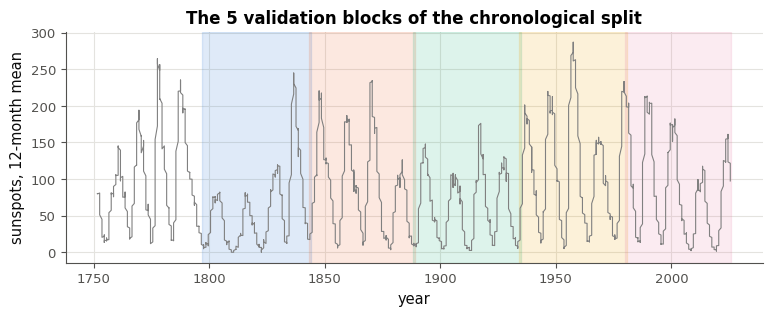

In [43]:
cv_shuffle_19 = KFold(n_splits=5, shuffle=True, random_state=0)
groups_19 = years_19 // 10 * 10
cv_groups_19 = GroupKFold(n_splits=5)
cv_time_19 = TimeSeriesSplit(n_splits=5)

if not filled(cv_shuffle_19, groups_19, cv_groups_19, cv_time_19):
    print("⏳ Ex 8.19 : pas encore fait.")
else:
    try:
        table_19 = {}
        for model_name_19, model_19 in [("1-NN", KNeighborsRegressor(n_neighbors=1)), ("linear", LinearRegression())]:
            for cv_name_19, cv_19, groups_used_19 in [("shuffled k-fold", cv_shuffle_19, None),
                                                      ("decades (groups)", cv_groups_19, groups_19),
                                                      ("chronological", cv_time_19, None)]:
                table_19[(model_name_19, cv_name_19)] = sklearn_cross_val_score(model_19, X_19, y_19, cv=cv_19,
                                                                                groups=groups_used_19).mean()
    except Exception as error_19:   # noqa: BLE001 - a wrong splitter or groups of the wrong length
        print(f"❌ Ex 8.19 : la validation croisée a échoué ({type(error_19).__name__}: {error_19}). "
              "Vérifie tes découpeurs et la longueur de groups_19 (un groupe par échantillon).")
    else:
        print(pd.Series(table_19).unstack().round(3))
        time_ok_19 = all(np.max(train) < np.min(val) for train, val in cv_time_19.split(X_19))
        verdict("8.19", time_ok_19, "chronologique : à chaque tour, l'entraînement est avant la validation.",
                "cv_time_19 met des échantillons postérieurs à la validation dans l'entraînement.")
        decades_19 = np.asarray(groups_19)
        groups_ok_19 = len(decades_19) == len(X_19) and all(
            not set(decades_19[train]) & set(decades_19[val]) for train, val in cv_groups_19.split(X_19, y_19, decades_19))
        verdict("8.19", groups_ok_19, "par groupes : aucune décennie n'est des deux côtés.",
                "une décennie se retrouve des deux côtés : groups_19 doit donner la décennie de chaque échantillon, "
                "et cv_groups_19 garder chaque groupe entier.")
        gap_nn_19 = table_19[("1-NN", "shuffled k-fold")] - table_19[("1-NN", "decades (groups)")]
        verdict("8.19", gap_nn_19 > 0.1,
                f"le 1-NN perd {fr(gap_nn_19, 2)} de R² quand les décennies restent entières : le mélange le flattait.",
                "attendu un R² plus haut pour le 1-NN avec la k-fold mélangée qu'avec les décennies : vérifie tes découpeurs.")
        fig, ax = plt.subplots(figsize=(9, 3))
        ax.plot(years_19 + 0.5, y_19, color="gray", lw=0.8)
        for k_19, (_, val_19) in enumerate(cv_time_19.split(X_19)):
            ax.axvspan(years_19[val_19[0]], years_19[val_19[-1]] + 1, alpha=0.15, color=f"C{k_19}")
        ax.set(xlabel="year", ylabel="sunspots, 12-month mean", title="The 5 validation blocks of the chronological split")
        plt.show()

💡 Avec la k-fold mélangée, chaque mois de validation a ses voisins dans l'entraînement : leurs 24 valeurs passées sont presque les mêmes, et leurs cibles aussi. Le plus proche voisin recopie la cible du mois voisin et obtient un $R^2$ de 0,933 ; en gardant les décennies entières, il tombe à 0,782, et à 0,670 en découpage chronologique, le plus proche de l'usage réel (prédire le futur à partir du passé, avec moins d'historique dans les premiers tours). La régression linéaire, qui ne retient pas les exemples, bouge à peine (0,857, 0,851, 0,833) : la fuite profite surtout aux modèles qui mémorisent. Aux frontières des décennies, les premiers échantillons d'une décennie de validation ont encore leurs voisins de la décennie précédente dans l'entraînement ; `gap` retire des échantillons entre l'entraînement et la validation pour couper ce lien.

### Ex 8.20 — Écrire tes propres tests pytest pour train_test_split 🛠️ ★★ ⏱️ 25 min
**Objectif :** écrire des tests unitaires qui vérifient les propriétés d'un découpage, et les éprouver sur des versions boguées.  
**Prérequis :** Ex 8.13 · 0A (pytest, assert) · fiche §8.3 · **Parcours :** C

Une collègue a écrit cinq versions de `train_test_split` (sans `stratify`) : `split_ok` est juste, `split_bug_1` à `split_bug_5` contiennent chacune un bug. Écris des **tests pytest** qui passent sur la bonne version et en attrapent le plus possible, **sans lire le code des versions boguées** dans un premier temps : pars des propriétés que promet la docstring de `train_test_split` (8.13).

Chaque test est une fonction dont le nom commence par `test_`, qui appelle `train_test_split(...)` et vérifie **une** propriété avec `assert`. Tes tests sont recopiés dans un fichier à part, qui n'importe que `math`, `numpy` (sous le nom `np`) et `pytest` : importe dans le test lui-même ce dont tu as besoin d'autre. Idées de propriétés : la taille du test ($\lceil t \cdot n \rceil$, avec au moins un cas où $t \cdot n$ n'est pas entier) ; des parties disjointes dont la réunion redonne toutes les lignes ; des tableaux qui restent alignés ; la même graine qui donne le même découpage ; les dernières lignes en test avec `shuffle=False`. Range tes tests dans la liste `TESTS_20`.

La vérification lance **vraiment** pytest (`wb.run_pytest`) : d'abord sur `split_ok`, renommée `train_test_split` (tous tes tests doivent passer), puis sur chaque version boguée (au moins un test doit échouer). Quand une version passe tous tes tests, lis son code, trouve le bug, et ajoute le test qui l'attrape.

Dans tes notes : quel bug était le plus difficile à attraper, et pourquoi ? Un test qui passe sur la version juste et sur toutes les versions boguées sert-il à quelque chose ?

In [44]:
def split_ok(*arrays, test_size=0.25, shuffle=True, rng=None):
    """A correct hold-out split (without stratify): test_size float -> ceil(test_size * n) test rows."""
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = math.ceil(test_size * n) if isinstance(test_size, float) else int(test_size)
    if rng is None:
        rng = np.random.default_rng()
    if shuffle:
        order = rng.permutation(n)
        test_idx, train_idx = order[:n_test], order[n_test:]
    else:
        test_idx, train_idx = np.arange(n - n_test, n), np.arange(n - n_test)
    result = []
    for a in arrays:
        result += [a[train_idx], a[test_idx]]
    return result


def split_bug_1(*arrays, test_size=0.25, shuffle=True, rng=None):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = int(test_size * n) if isinstance(test_size, float) else int(test_size)
    if rng is None:
        rng = np.random.default_rng()
    if shuffle:
        order = rng.permutation(n)
        test_idx, train_idx = order[:n_test], order[n_test:]
    else:
        test_idx, train_idx = np.arange(n - n_test, n), np.arange(n - n_test)
    result = []
    for a in arrays:
        result += [a[train_idx], a[test_idx]]
    return result


def split_bug_2(*arrays, test_size=0.25, shuffle=True, rng=None):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = math.ceil(test_size * n) if isinstance(test_size, float) else int(test_size)
    if rng is None:
        rng = np.random.default_rng()
    result = []
    for a in arrays:
        if shuffle:
            order = rng.permutation(n)
            test_idx, train_idx = order[:n_test], order[n_test:]
        else:
            test_idx, train_idx = np.arange(n - n_test, n), np.arange(n - n_test)
        result += [a[train_idx], a[test_idx]]
    return result


def split_bug_3(*arrays, test_size=0.25, shuffle=True, rng=None):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = math.ceil(test_size * n) if isinstance(test_size, float) else int(test_size)
    if rng is None:
        rng = np.random.default_rng()
    if shuffle:
        order = rng.permutation(n)
        test_idx, train_idx = order[:n_test], order[n_test - 1:]
    else:
        test_idx, train_idx = np.arange(n - n_test, n), np.arange(n - n_test)
    result = []
    for a in arrays:
        result += [a[train_idx], a[test_idx]]
    return result


def split_bug_4(*arrays, test_size=0.25, shuffle=True, rng=None):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = math.ceil(test_size * n) if isinstance(test_size, float) else int(test_size)
    rng = np.random.default_rng()
    if shuffle:
        order = rng.permutation(n)
        test_idx, train_idx = order[:n_test], order[n_test:]
    else:
        test_idx, train_idx = np.arange(n - n_test, n), np.arange(n - n_test)
    result = []
    for a in arrays:
        result += [a[train_idx], a[test_idx]]
    return result


def split_bug_5(*arrays, test_size=0.25, shuffle=True, rng=None):
    arrays = [np.asarray(a) for a in arrays]
    n = len(arrays[0])
    n_test = math.ceil(test_size * n) if isinstance(test_size, float) else int(test_size)
    if rng is None:
        rng = np.random.default_rng()
    if shuffle:
        order = rng.permutation(n)
        test_idx, train_idx = order[:n_test], order[n_test:]
    else:
        test_idx, train_idx = np.arange(n_test), np.arange(n_test, n)
    result = []
    for a in arrays:
        result += [a[train_idx], a[test_idx]]
    return result


BUGS_20 = [split_bug_1, split_bug_2, split_bug_3, split_bug_4, split_bug_5]

In [45]:
def test_sizes():
    """ceil(test_size * n) test rows, also when test_size * n is not a whole number."""
    for n, test_size, n_test in [(10, 0.25, 3), (8, 0.25, 2), (10, 3, 3)]:
        train, test = train_test_split(np.arange(n), test_size=test_size, rng=np.random.default_rng(0))
        assert len(test) == n_test and len(train) == n - n_test


def test_parts_are_disjoint_and_cover_everything():
    train, test = train_test_split(np.arange(50), test_size=0.3, rng=np.random.default_rng(1))
    assert sorted(np.concatenate([train, test]).tolist()) == list(range(50))


def test_rows_stay_aligned():
    X = np.arange(40).reshape(20, 2)
    y = np.arange(20) * 10
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, rng=np.random.default_rng(2))
    assert np.array_equal(X_train[:, 0] // 2 * 10, y_train) and np.array_equal(X_test[:, 0] // 2 * 10, y_test)


def test_same_seed_same_split():
    first = train_test_split(np.arange(30), rng=np.random.default_rng(3))
    second = train_test_split(np.arange(30), rng=np.random.default_rng(3))
    assert np.array_equal(first[1], second[1])


def test_last_rows_without_shuffle():
    train, test = train_test_split(np.arange(10), test_size=0.3, shuffle=False)
    assert test.tolist() == [7, 8, 9] and train.tolist() == list(range(7))


TESTS_20 = [test_sizes, test_parts_are_disjoint_and_cover_everything, test_rows_stay_aligned,
            test_same_seed_same_split, test_last_rows_without_shuffle]

if True:
    if not filled(TESTS_20) or not list(TESTS_20):
        raise NotImplementedError
    tests_20 = list(TESTS_20)
    names_20 = [getattr(test, "__name__", repr(test)) for test in tests_20]
    good_20 = None
    if not all(callable(test) for test in tests_20):
        print("❌ Ex 8.20 : TESTS_20 doit être une liste de fonctions de test, pas de leurs noms ni de leurs résultats.")
    elif not all(name.startswith("test_") for name in names_20):
        print(f"❌ Ex 8.20 : pytest ne lance que les fonctions dont le nom commence par test_ : renomme "
              f"{[name for name in names_20 if not name.startswith('test_')]}.")
    else:
        good_20 = wb.run_pytest(tests_20, subject=split_ok, name="train_test_split", quiet=True)
        if "NameError" in good_20.output:
            print("❌ Ex 8.20 : un de tes tests utilise un nom que le fichier de test ne connaît pas (il n'importe que "
                  "math, numpy sous le nom np, et pytest) : importe ce qu'il te faut dans le test lui-même.")
        verdict("8.20", good_20.ok, f"tes {good_20.passed} tests passent sur la version juste (split_ok).",
                f"un de tes tests échoue sur la version juste : ce test-là est faux ({good_20.summary}).")
    if good_20 is None:
        pass
    elif not good_20.ok:
        print(good_20.output[-1500:])
    else:
        for bug_20 in BUGS_20:
            result_20 = wb.run_pytest(tests_20, subject=bug_20, name="train_test_split", quiet=True)
            verdict("8.20", not result_20.ok, f"{bug_20.__name__} attrapée ({result_20.failed} test(s) en échec).",
                    f"{bug_20.__name__} passe tous tes tests : compare son code à split_ok, et ajoute le test "
                    "d'une propriété de la docstring qu'elle viole.")

✅ Ex 8.20 : tes 5 tests passent sur la version juste (split_ok).


✅ Ex 8.20 : split_bug_1 attrapée (1 test(s) en échec).


✅ Ex 8.20 : split_bug_2 attrapée (1 test(s) en échec).


✅ Ex 8.20 : split_bug_3 attrapée (2 test(s) en échec).


✅ Ex 8.20 : split_bug_4 attrapée (1 test(s) en échec).


✅ Ex 8.20 : split_bug_5 attrapée (1 test(s) en échec).


💡 `split_bug_1` arrondit la taille du test vers le bas (attrapée par $n = 10$, $t = 0{,}25$) ; `split_bug_2` mélange chaque tableau avec sa propre permutation (attrapée par l'alignement) ; `split_bug_3` met une ligne des deux côtés (attrapée par « disjoint et complet ») ; `split_bug_4` ignore le générateur reçu (attrapée par « même graine, même découpage ») ; `split_bug_5` met les **premières** lignes en test quand `shuffle=False`. Un test qui ne casse sur aucune version boguée peut rester utile (il protège contre un bug qu'on n'a pas encore imaginé), mais il ne prouve rien ici : c'est l'idée du *mutation testing*.

## Partie C · La validation croisée dans mylearn

Tu complètes `model_selection.py` : la k-fold stratifiée, `clone` et `cross_val_score`, puis tu mesures ce que la validation croisée apporte par rapport à un simple hold-out. Le modèle est le centroïde le plus proche de scikit-learn (`NearestCentroid`, le même que ton modèle du ch. 7), sur la longueur et l'épaisseur du bec des manchots.

### Ex 8.21 — k-fold stratifiée : stratified_kfold_indices 🔨 ★★★ ⏱️ 40 min
**Objectif :** écrire une k-fold dont chaque fold garde les proportions des classes.  
**Prérequis :** Ex 8.14 · fiche §8.5.1 (stratifier les folds) · **Fil rouge :** Penguins · **mylearn :** `model_selection.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/model_selection.py`, mêmes règles qu'en 8.13 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris `stratified_kfold_indices(y, n_splits=5, shuffle=False, rng=None)` (lis sa docstring et le mini-exemple de la fiche) :
- lève une `ValueError` si `n_splits < 2` ou si `n_splits` dépasse le nombre d'échantillons ; émets un `UserWarning` (`warnings.warn(..., UserWarning)`) si une classe a moins de `n_splits` membres ;
- trie les indices **par label**, avec un tri **stable** (`np.argsort(y, kind="stable")` : à l'intérieur d'une classe, l'ordre d'origine est gardé) ; avec `shuffle=True`, mélange d'abord les indices **de chaque classe** avec `rng`, puis mets les classes bout à bout dans l'ordre trié des labels ;
- distribue cet ordre comme des cartes : le fold `i` reçoit les positions `i`, `i + k`, `i + 2k`… (`order[i::k]`) ;
- renvoie une liste de `n_splits` paires `(train_idx, val_idx)`, chaque partie triée en ordre croissant.

La vérification affiche l'exemple de la docstring, puis vérifie le tableau des effectifs de chaque espèce dans chacun des 5 folds des 333 manchots (une ligne par fold, colonnes Adélie, Chinstrap, Gentoo), le compare à `StratifiedKFold` de scikit-learn, et lance les tests.

Dans tes notes : compare ce tableau à celui de la k-fold sans mélange de 8.14. Pourquoi les effectifs d'une espèce diffèrent-ils au plus d'une unité d'un fold à l'autre ?

In [46]:
if True:
    splits_21 = mylearn.model_selection.stratified_kfold_indices([0, 0, 0, 0, 1, 1], n_splits=2)
    if split_pairs("8.21", "stratified_kfold_indices", splits_21, 2):
        print("docstring example:", [(np.asarray(a).tolist(), np.asarray(b).tolist()) for a, b in splits_21])
    splits_21 = mylearn.model_selection.stratified_kfold_indices(species, n_splits=5)
    if split_pairs("8.21", "stratified_kfold_indices", splits_21, 5):
        names_21 = ["Adelie", "Chinstrap", "Gentoo"]
        table_21 = np.array([[int(np.sum(species[np.asarray(val)] == name)) for name in names_21]
                             for _, val in splits_21])
        print(pd.DataFrame(table_21, columns=names_21, index=[f"fold {i + 1}" for i in range(len(table_21))]))
        print_answer("8.21", table_21, computed=True)
        oracle_21 = [sorted(int(np.sum(species[val] == name)) for _, val in StratifiedKFold(5).split(X_peng, species))
                     for name in names_21]
        verdict("8.21", [sorted(column) for column in table_21.T.tolist()] == oracle_21,
                "pour chaque espèce, les mêmes effectifs par fold que StratifiedKFold de scikit-learn (à l'ordre des folds près).",
                "tes effectifs par espèce diffèrent de ceux de StratifiedKFold : relis la règle de la docstring.")
        order_21 = np.argsort(species, kind="stable")              # the rule of the docstring, with NumPy
        verdict("8.21", all(np.array_equal(np.sort(np.asarray(val)), np.sort(order_21[i::5]))
                            for i, (_, val) in enumerate(splits_21)),
                "chaque fold contient exactement les manchots prévus par la docstring (tri stable, puis une carte par fold).",
                "les manchots de tes folds ne sont pas ceux de la règle de la docstring : trie les indices par label avec "
                "un tri stable (np.argsort(..., kind=\"stable\")), puis donne au fold i les positions i, i + k, i + 2k…")
    run_mylearn_tests(impl="ref", keyword="test_stratified_kfold_indices_")

docstring example: [([1, 3, 5], [0, 2, 4]), ([0, 2, 4], [1, 3, 5])]
        Adelie  Chinstrap  Gentoo
fold 1      30         13      24
fold 2      29         14      24
fold 3      29         14      24
fold 4      29         14      23
fold 5      29         13      24
8.21: [[30, 13, 24], [29, 14, 24], [29, 14, 24], [29, 14, 23], [29, 13, 24]]
✅ Ex 8.21 : pour chaque espèce, les mêmes effectifs par fold que StratifiedKFold de scikit-learn (à l'ordre des folds près).
✅ Ex 8.21 : chaque fold contient exactement les manchots prévus par la docstring (tri stable, puis une carte par fold).


pytest: 17 passed, 87 deselected in 1.22s


In [47]:
wb.record("8.21", table_21, mistakes={"tes classes sont rangées dans leur ordre d'apparition dans le fichier : la docstring trie les indices par valeur de label (tri stable)": [[30, 14, 23], [29, 14, 24], [29, 14, 24], [29, 13, 24], [29, 13, 24]]})

WB_ANSWER {"decimals": 0, "element_hashes": ["e903f0ba79af2bb190d9e5b48f3f478cd8fe2093a405d247bcfa1ddb4fde097a", "ed5063008ddd882fdfdfbabab439271bf6d6c28203165647c23cd1be66f2c9d9", "4282c7904dd16784476de0062057968e9f9e18f10981de7eaec3bec8465bd96f", "c2f7f08ef0bc135e672ab72b5e8126bd53cdf12841e41f7a6dd01796c3c88b25", "3a14736baf6342b7c37fa3605df4865a1f24c96aaf24ead5540c6a8aff05c412", "00b85c1adaaac374851231222810b6199282ed3469f63f1253d161378ab157f3", "ddc0bc974fee8c82f4d1f6c330c1f2ede4f8f2ae773e7678c2d660be061b8926", "9d9e826a3ce1ef61a6cba732136304bc2fbe9a935abd41105b2bd6add50005f0", "34db1e90c66e5113a83abf3385118e899d6da93de312127f19398b04a59b09dc", "b2f220a206cf9a387eac88f127cf7a573fb63e5d4135de65fb4317eaf5a5d3ea", "36ea8094f5b73f0b71b3a87b1cf43b281b2854dbf5f4b4a1e32590c660cd201c", "aae0095fa78cb9453d6d4286f8c460be8fb6e0fba9cd6f0dc89cba9ff56011d3", "0b415db83d46933d97b85fb8041a82c38bd8bab0ab4209546707a5bea9402b31", "7b2006b595d8bbaabc21346b051c75998f42013244c802f615d877788313ad8f", "50

💡 Le tableau vaut, fold par fold : (30, 13, 24), (29, 14, 24), (29, 14, 24), (29, 14, 23), (29, 13, 24) manchots Adélie, Chinstrap et Gentoo. Chaque espèce occupe un bloc de positions consécutives de l'ordre trié, et la distribution « une carte par fold » donne à chaque fold soit $\lfloor n_c / k \rfloor$, soit $\lfloor n_c / k \rfloor + 1$ membres de la classe $c$ ; les folds ont 67, 67, 67, 66 et 66 manchots. Sans mélange ni stratification (8.14), deux folds ne contenaient que des Adélie et le dernier que des Chinstrap. scikit-learn range les classes dans leur ordre d'apparition (Adélie, Gentoo, Chinstrap) et répartit les exemples d'une classe par blocs : pour chaque espèce, il obtient les mêmes effectifs par fold, mais pas dans les mêmes folds (son tableau commence par (30, 14, 23)), et les manchots de chaque fold diffèrent.

### Ex 8.22 — clone et cross_val_score 🔨 ★★★ ⏱️ 45 min
**Objectif :** écrire le clonage d'un estimateur et la validation croisée de mylearn, et les comparer à scikit-learn.  
**Prérequis :** Ex 8.14 · Ex 8.21 · ch. 7 (estimateurs à la scikit-learn) · fiche §8.5.1 (cloner, `cross_val_score`) · **Fil rouge :** Penguins · **mylearn :** `model_selection.py` · **Parcours :** R, M, C

> **mylearn** : dans `mon_travail/mylearn/model_selection.py`, mêmes règles qu'en 8.13 (NumPy permis, scikit-learn non). Enregistre, puis relance la cellule de vérification.

Écris (lis les docstrings) :
- `clone(estimator)` : relis les attributs de l'estimateur (`vars(estimator)`) dont le nom ne commence ni ne finit par `_` (ses hyperparamètres), copie chaque valeur avec `copy.deepcopy`, et renvoie `type(estimator)(**params)`. Ne rattrape pas l'erreur d'un `__init__` qui refuse ces arguments : elle doit remonter (`TypeError`) ;
- `cross_val_score(estimator, X, y, cv=5, scoring=None)` : convertis `X` et `y` avec `np.asarray` (un `DataFrame` indexé par `X[idx]` sélectionnerait des colonnes) ; lève une `ValueError` si leurs longueurs diffèrent, ou si `scoring` vaut `None` et que l'estimateur n'a pas de méthode `score`. Un `cv` entier `k` donne `kfold_indices(len(X), k)`, **sans mélange** (une liste de paires est utilisée telle quelle). Pour chaque paire `(train_idx, val_idx)` : un **clone** de l'estimateur, entraîné sur les lignes d'entraînement, noté sur celles de validation, avec `scoring(fitted_clone, X_val, y_val)` ou `fitted_clone.score(X_val, y_val)`. N'enchaîne pas `.fit(...).score(...)` : appelle `fit`, puis `score`. Renvoie un tableau NumPy de flottants, un score par paire. L'estimateur reçu n'est **jamais** entraîné.

La vérification essaie `clone` sur des modèles de scikit-learn, puis calcule, avec `NearestCentroid` sur la longueur et l'épaisseur du bec :
a) les 5 scores de `cv=5`, les manchots dans l'ordre du fichier (triés par espèce) ;
b) la moyenne des 5 scores avec les folds stratifiés de ta fonction 8.21 ;
et compare ces scores à `cross_val_score` de scikit-learn, avant de lancer les tests.

Dans tes notes : pourquoi les scores de a) sont-ils si irréguliers ? Avec `cv=5`, `cross_val_score` de scikit-learn ne donne pas les mêmes scores que le tien sur les mêmes données : pourquoi (fiche, encadré 🕰️ sur les découpeurs) ? Pourquoi faut-il cloner l'estimateur à chaque tour, au lieu de réutiliser le même objet ?

In [48]:
if True:
    model_22 = NearestCentroid(shrink_threshold=0.5)
    copy_22 = mylearn.model_selection.clone(model_22)
    if returned("8.22", "clone", copy_22):
        verdict("8.22", copy_22 is not model_22 and type(copy_22) is NearestCentroid
                and copy_22.get_params() == model_22.get_params(),
                "clone fabrique un nouveau NearestCentroid avec les mêmes hyperparamètres.",
                "clone doit renvoyer un NOUVEL objet de la même classe, avec les mêmes hyperparamètres.")
        copy_trained_22 = mylearn.model_selection.clone(NearestCentroid().fit(X_peng, species))
        verdict("8.22", copy_trained_22 is not None and not hasattr(copy_trained_22, "centroids_"),
                "le clone d'un modèle entraîné n'a rien appris (pas de centroids_).",
                "le clone d'un modèle entraîné doit être un nouveau modèle, sans aucun attribut appris (ceux qui finissent par _).")
    A_22 = X_peng[:, :2]                                   # bill length and depth, raw
    scores_22 = mylearn.model_selection.cross_val_score(NearestCentroid(), A_22, species, cv=5)
    if returned("8.22", "cross_val_score", scores_22):
        print("a) cv=5, folds in the order of the file (sorted by species):", np.round(np.asarray(scores_22, dtype=float), 3))
        print_answer("8.22a", scores_22, computed=True)
        try:
            folds_22 = mylearn.model_selection.stratified_kfold_indices(species, n_splits=5)
        except NotImplementedError:
            folds_22 = None
            print("⏳ Ex 8.22 : b) a besoin de stratified_kfold_indices (8.21) : reviens ici quand tu l'auras écrite.")
        order_22 = np.argsort(species, kind="stable")      # the rule of the docstring of 8.21, with NumPy
        if folds_22 is None or not split_pairs("8.22", "stratified_kfold_indices (8.21)", folds_22, 5):
            pass
        elif not all(np.array_equal(np.sort(np.asarray(val)), np.sort(order_22[i::5])) for i, (_, val) in enumerate(folds_22)):
            print("❌ Ex 8.22 : b) utilise tes folds de 8.21, qui ne suivent pas encore la règle de la docstring de "
                  "stratified_kfold_indices : corrige d'abord 8.21 (ses tests disent ce qui ne va pas).")
        else:
            stratified_22 = mylearn.model_selection.cross_val_score(NearestCentroid(), A_22, species, cv=folds_22)
            print("b) stratified folds:", np.round(np.asarray(stratified_22, dtype=float), 3),
                  "· mean", round(float(np.mean(stratified_22)), 4))
            print_answer("8.22b", float(np.mean(stratified_22)), computed=True)
            oracle_22 = sklearn_cross_val_score(NearestCentroid(), A_22, species,
                                                cv=[(np.asarray(a), np.asarray(b)) for a, b in folds_22])
            verdict("8.22", np.allclose(np.asarray(stratified_22, dtype=float), oracle_22),
                    "les mêmes scores que cross_val_score de scikit-learn, sur les mêmes folds.",
                    "tes scores diffèrent de ceux de scikit-learn sur les mêmes folds : relis la docstring.")
        print("scikit-learn's cross_val_score with cv=5 (StratifiedKFold for a classifier):",
              np.round(sklearn_cross_val_score(NearestCentroid(), A_22, species, cv=5), 3))
    run_mylearn_tests(impl="ref", keyword="test_clone_ or test_cross_val_score_")

✅ Ex 8.22 : clone fabrique un nouveau NearestCentroid avec les mêmes hyperparamètres.
✅ Ex 8.22 : le clone d'un modèle entraîné n'a rien appris (pas de centroids_).
a) cv=5, folds in the order of the file (sorted by species): [0.97  0.955 0.955 0.636 0.788]
8.22a: [0.9701, 0.9552, 0.9552, 0.6364, 0.7879]
b) stratified folds: [0.91  0.851 0.881 0.833 0.909] · mean 0.8768
8.22b: 0.8768430574400723
✅ Ex 8.22 : les mêmes scores que cross_val_score de scikit-learn, sur les mêmes folds.
scikit-learn's cross_val_score with cv=5 (StratifiedKFold for a classifier): [0.94  0.925 0.896 0.833 0.803]


pytest: 23 passed, 81 deselected in 1.19s


In [49]:
wb.record("8.22a", scores_22, decimals=4)
wb.record("8.22b", float(np.mean(stratified_22)), decimals=4, mistakes={"c'est la moyenne des scores de a) : la question demande les folds stratifiés de 8.21": float(np.mean(scores_22))})

⚠️ Ex 8.22a : un élément est proche d'une limite d'arrondi ; envisage un autre nombre de décimales.
WB_ANSWER {"decimals": 4, "element_coarse": [["70e5e7e828fa730a36b0502b060605023868071d98a1c8f1ec6353b061768eff"], ["69ddbafcf34b0e785b28cb6cb9118ba055e0f07f5006580a8fd3cb53e554eb66"], ["ba7fc41b1e8ff7ff9aabd6c02ac7b1bccfb642e31dc8201a4a8576390a3633c2"], ["20efebbe41903a2ccb2b14d11740a7a063374467158e6424be42d9b122dbe60e"], ["21f99e44c294d1be1215fe827caecbded1ecbae981c8f6ebd00b6a1cd9c007aa"]], "element_hashes": ["9ea0bda4ae70af22575ec65b38a2e4281bd1d7db64a99084c771bda93d301659", "697284a0781ccabe29eb0e16364800642040b390aa8ee29429882008462d8f81", "a94f9d3ff22e2b483bbdab622689204a48642302b84364db2ba31b0e32ca55a4", "937941cf77376226347e3b56bb97cfb24e7d3c7adb0cc653baa05a58c98e82ea", "d66694403d5a97fa3f8b8f418ad2d240e80360575b5325721500dc9acf08ca22"], "hash": "e7698b59e8c489733bdd461be9750546a8cd236c88fb4a15f60a165dde46fcbc", "id": "8.22a", "kind": "array", "shape": [5]}
📝 Ex 8.22a : réponse e

💡 Dans l'ordre du fichier, les deux premiers folds ne contiennent que des Adélie, et le dernier que des Chinstrap : les scores (0,970, 0,955, 0,955, 0,636, 0,788) dépendent surtout de l'espèce du fold, et au dernier tour le modèle n'a appris les Chinstrap que sur deux individus. Avec des folds stratifiés, les scores sont plus réguliers, autour de 0,877 en moyenne. Avec `cv=5`, scikit-learn utilise `StratifiedKFold` pour un classifieur (sans mélanger), d'où d'autres folds et d'autres scores. Réutiliser le même objet ferait dépendre chaque tour des précédents dès que `fit` ne repart pas de zéro (un réseau qui reprend ses poids, un `warm_start`), et l'objet passé à la fonction ressortirait modifié : `clone` garantit un modèle neuf à chaque tour.

### Ex 8.23 — Variabilité de l'évaluation : hold-out répétés contre k-fold 🔬 ★★★ ⏱️ 40 min
**Objectif :** mesurer combien une estimation de l'accuracy dépend du découpage, avec un hold-out et avec une validation croisée.  
**Prérequis :** Ex 8.22 · Ex 8.13 · Ex 8.14 · ch. 2 (dispersion) · fiche §8.5.1 · **Fil rouge :** Penguins · **Parcours :** M, C

Combien une accuracy estimée dépend-elle du hasard du découpage ? Écris, avec **tes** fonctions de `mylearn.model_selection` et `NearestCentroid` de scikit-learn :
- `holdout_scores_23(X, y, n_repeats)` : pour chaque graine `seed` de 0 à `n_repeats - 1`, `train_test_split(X, y, test_size=0.25, rng=np.random.default_rng(seed))`, puis l'accuracy de `NearestCentroid` entraîné sur l'entraînement et noté sur le test ; renvoie les `n_repeats` accuracies ;
- `cv_means_23(X, y, n_repeats)` : pour chaque graine, `kfold_indices(len(X), 5, shuffle=True, rng=np.random.default_rng(seed))`, puis la **moyenne** des 5 scores de `cross_val_score` ; renvoie les `n_repeats` moyennes.

La vérification lance les deux fonctions 200 fois chacune sur la longueur et l'épaisseur du bec (brutes), compare les moyennes et les dispersions, et superpose les deux histogrammes.

Dans tes notes : entre quelles valeurs l'accuracy d'un hold-out peut-elle tomber, selon le tirage ? Pourquoi la moyenne d'une 5-fold varie-t-elle beaucoup moins ? Combien d'entraînements chaque méthode coûte-t-elle ? Cette faible dispersion veut-elle dire que l'accuracy du modèle sur de **nouveaux** manchots est connue à ce point près (fiche, « la dispersion des folds n'est pas une erreur type ») ?

hold-out (25 % test) : mean 0.881, std 0.035, from 0.786 to 0.964
mean of a 5-fold     : mean 0.877, std 0.005, from 0.862 to 0.889
✅ Ex 8.23 : les deux méthodes visent le même score : leurs moyennes sont proches.
✅ Ex 8.23 : la moyenne d'une 5-fold varie 7,5 fois moins d'un tirage à l'autre qu'un hold-out.


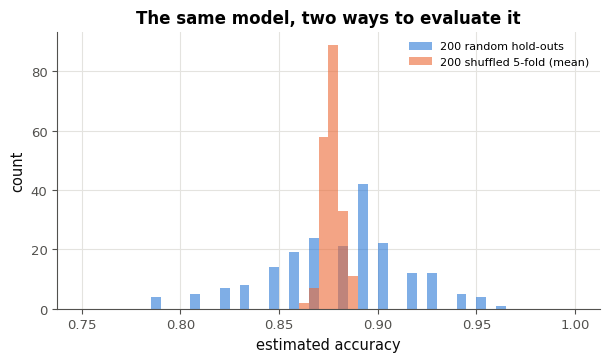

In [50]:
def holdout_scores_23(X, y, n_repeats):
    """Test accuracy of NearestCentroid on n_repeats random hold-out splits (test_size=0.25, seeds 0, 1, ...)."""
    scores = []
    for seed in range(n_repeats):
        X_train, X_test, y_train, y_test = mylearn.model_selection.train_test_split(
            X, y, test_size=0.25, rng=np.random.default_rng(seed))
        scores.append(NearestCentroid().fit(X_train, y_train).score(X_test, y_test))
    return np.array(scores)


def cv_means_23(X, y, n_repeats):
    """Mean accuracy of a shuffled 5-fold cross-validation of NearestCentroid, repeated n_repeats times (seeds 0, 1, ...)."""
    means = []
    for seed in range(n_repeats):
        folds = mylearn.model_selection.kfold_indices(len(X), n_splits=5, shuffle=True, rng=np.random.default_rng(seed))
        means.append(np.mean(mylearn.model_selection.cross_val_score(NearestCentroid(), X, y, cv=folds)))
    return np.array(means)


if True:
    A_23 = X_peng[:, :2]                                   # bill length and depth, raw (accuracy about 0.88)
    with threadpool_limits(limits=1):                      # 1 200 small fits: one thread is faster
        holdout_23 = holdout_scores_23(A_23, species, 200)
        cv_23 = cv_means_23(A_23, species, 200)
    if returned("8.23", "holdout_scores_23", holdout_23) and returned("8.23", "cv_means_23", cv_23):
        holdout_23, cv_23 = np.asarray(holdout_23, dtype=float), np.asarray(cv_23, dtype=float)
        if holdout_23.shape != (200,) or cv_23.shape != (200,):
            print(f"❌ Ex 8.23 : attendu 200 valeurs par fonction, reçu les formes {holdout_23.shape} et {cv_23.shape}.")
        else:
            for name_23, values_23 in [("hold-out (25 % test)", holdout_23), ("mean of a 5-fold", cv_23)]:
                print(f"{name_23:21s}: mean {values_23.mean():.3f}, std {values_23.std():.3f}, "
                      f"from {values_23.min():.3f} to {values_23.max():.3f}")
            verdict("8.23", abs(holdout_23.mean() - cv_23.mean()) < 0.01,
                    "les deux méthodes visent le même score : leurs moyennes sont proches.",
                    "les moyennes des deux méthodes devraient être proches : relis les deux procédures imposées.")
            verdict("8.23", holdout_23.std() > 3 * cv_23.std(),
                    f"la moyenne d'une 5-fold varie {fr(holdout_23.std() / cv_23.std(), 1)} fois moins d'un tirage à l'autre "
                    "qu'un hold-out.",
                    "attendu une dispersion bien plus faible pour la moyenne des 5-fold que pour le hold-out.")
            fig, ax = plt.subplots(figsize=(7, 3.6))
            bins_23 = np.linspace(0.75, 1.0, 51)
            ax.hist(holdout_23, bins=bins_23, alpha=0.6, label="200 random hold-outs")
            ax.hist(cv_23, bins=bins_23, alpha=0.6, label="200 shuffled 5-fold (mean)")
            ax.set(xlabel="estimated accuracy", ylabel="count", title="The same model, two ways to evaluate it")
            ax.legend(fontsize=8)
            plt.show()

💡 Sur 200 tirages, l'accuracy d'un hold-out va d'environ 0,79 à 0,96 (écart-type 0,035) : un seul découpage peut faire paraître le modèle médiocre ou excellent. La moyenne d'une 5-fold reste entre 0,86 et 0,89 (écart-type 0,005, environ 7,5 fois moins), parce qu'elle note **chaque** manchot une fois et moyenne cinq modèles : le hasard du découpage s'y compense. Elle coûte 5 entraînements au lieu d'un. Mais les 200 répétitions utilisent toujours les **mêmes** 333 manchots : la faible dispersion mesure l'effet du découpage, pas l'incertitude face à de nouveaux manchots, qui reste de l'ordre de l'erreur type d'une accuracy sur 333 exemples (environ 0,018).

## Partie D · Fuites, comparaisons honnêtes et défi

Trois expériences sur les pièges de l'évaluation, puis un défi. Les manchots reviennent, avec le découpage du ch. 1 (`TRAIN_CH1`, `TEST_CH1`) et deux nouvelles cibles : l'**île** (8.24) et le **sexe** (8.27).

### Ex 8.24 — Un notebook trop beau pour être vrai : quatre fuites à corriger 🐛 ★★★ ⏱️ 35 min
**Objectif :** repérer les fuites d'un protocole d'évaluation et le refaire honnêtement.  
**Prérequis :** Ex 8.22 · Ex 8.21 · Ex 8.3 · fiche §8.3 (fuites), §8.5 (« seulement si tout est refait dans la boucle ») · **Fil rouge :** Penguins · **Parcours :** R, C

Une collègue annonce qu'on peut deviner l'**île** d'un manchot (Biscoe, Dream ou Torgersen) à partir de ses quatre mesures, avec une accuracy de près de 0,9. Son code est la fonction `colleague_24`, en six étapes, A à F : lis-la attentivement.

a) `leaky_steps_24` : les lettres des étapes qui créent une fuite de données (par exemple `"XY"`).

Écris ensuite `honest_24()`, la même étude **sans fuite**. Pour que tout le monde trouve les mêmes nombres, suis ce protocole :
1. pas d'augmentation ; les quatre mesures des 333 manchots (`X_peng`) et leur île (`island`) ;
2. le découpage du ch. 1, **en premier** : 233 manchots d'entraînement (`TRAIN_CH1`), 100 de test (`TEST_CH1`) ;
3. le choix entre `IslandPipeline("1-NN")` et `IslandPipeline("centroid")` (fournie : elle refait la sélection des deux mesures et la standardisation dans son `fit`, sur les seules lignes qu'elle reçoit) se fait avec **ta** `cross_val_score` sur les 233 manchots d'entraînement, avec `cv=stratified_kfold_indices(island[TRAIN_CH1], 5)` : garde la meilleure moyenne (`"1-NN"` en cas d'égalité) ;
4. le pipeline retenu est réentraîné sur les 233 manchots, puis noté **une seule fois** sur les 100 du test.

`honest_24()` renvoie `(model_name, test_accuracy)`, le nom du modèle retenu et son accuracy de test. La vérification contrôle :
b) le modèle retenu ;
c) son accuracy de test.

Dans tes notes : pour chaque fuite, ce qu'elle laisse passer du test vers le modèle, et ce qu'elle a coûté ici. Laquelle pèse le plus, et pourquoi avec le plus proche voisin ? L'étape D change-t-elle les mesures choisies sur ces données ? Le test aurait-il préféré l'autre modèle ? Fallait-il pour autant le choisir ?

In [51]:
island = penguins["island"].to_numpy()                       # Biscoe, Dream or Torgersen


def spread_score_24(x, labels):
    """How far apart the class means of the feature x are, in standard deviations of x."""
    means = [x[labels == label].mean() for label in np.unique(labels)]
    return (max(means) - min(means)) / x.std()


def select_2(X, labels):
    """The indices (sorted) of the two columns of X with the largest spread_score_24."""
    scores = np.array([spread_score_24(X[:, j], labels) for j in range(X.shape[1])])
    return np.sort(np.argsort(-scores, kind="stable")[:2])


class IslandPipeline:
    """select_2, then standardisation, then the model ("1-NN" or "centroid"): every step is learnt in fit,
    on the rows that fit receives."""

    def __init__(self, model="1-NN"):
        self.model = model

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=float), np.asarray(y)
        self.columns_ = select_2(X, y)
        A = X[:, self.columns_]
        self.mean_, self.std_ = A.mean(axis=0), A.std(axis=0)
        model = OneNN() if self.model == "1-NN" else NearestCentroid()
        self.model_ = model.fit((A - self.mean_) / self.std_, y)
        return self

    def predict(self, X):
        A = np.asarray(X, dtype=float)[:, self.columns_]
        return self.model_.predict((A - self.mean_) / self.std_)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))


def colleague_24():
    """The colleague's notebook: guess the island of a penguin from its measurements."""
    # Step A: the four measurements of the 333 penguins, and their island
    X, y = X_peng.copy(), island.copy()
    # Step B: "data augmentation": every penguin twice more, with a tiny measurement noise
    rng = np.random.default_rng(24)
    X = np.vstack([X] + [X + rng.normal(0.0, 0.01, X.shape) * X.std(axis=0) for _ in range(2)])
    y = np.concatenate([y, y, y])
    # Step C: standardisation, with the mean and the standard deviation of all the rows
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Step D: keep the two measurements whose island means differ the most (select_2 on all the rows)
    X = X[:, select_2(X, y)]
    # Step E: split, 70 % for training and 30 % for the test
    X_train, X_test, y_train, y_test = sklearn_train_test_split(X, y, test_size=0.3, random_state=0)
    # Step F: try two models, keep the one with the best test accuracy, and report that accuracy
    scores = {"1-NN": OneNN().fit(X_train, y_train).score(X_test, y_test),
              "centroid": NearestCentroid().fit(X_train, y_train).score(X_test, y_test)}
    best = max(scores, key=scores.get)
    return best, scores[best]


best_24, reported_24 = colleague_24()
print(f"the colleague reports: model {best_24}, test accuracy {reported_24:.3f}")
print("islands of the 333 penguins:", {name: int(count) for name, count in zip(*np.unique(island, return_counts=True))})

the colleague reports: model 1-NN, test accuracy 0.893
islands of the 333 penguins: {'Biscoe': 163, 'Dream': 123, 'Torgersen': 47}


In [52]:
leaky_steps_24 = "BCDF"


def honest_24():
    """The honest version of the colleague's study: returns (model_name, test_accuracy)."""
    X_train, y_train = X_peng[TRAIN_CH1], island[TRAIN_CH1]          # step 2: the split of ch. 1, first
    folds = mylearn.model_selection.stratified_kfold_indices(y_train, n_splits=5)
    cv_means = {name: float(np.mean(mylearn.model_selection.cross_val_score(IslandPipeline(name), X_train, y_train,
                                                                            cv=folds)))
                for name in ("1-NN", "centroid")}                     # step 3: the choice, on the training part only
    print("cross-validation on the 233 training penguins:", {name: round(value, 3) for name, value in cv_means.items()})
    best = max(cv_means, key=cv_means.get)                            # 1-NN first on ties
    final = IslandPipeline(best).fit(X_train, y_train)                # step 4: refit, then the test, once
    return best, final.score(X_peng[TEST_CH1], island[TEST_CH1])


print_answer("8.24a", leaky_steps_24)
if True:
    result_24 = honest_24()
    if returned("8.24", "honest_24", result_24):
        if not (isinstance(result_24, (tuple, list)) and len(result_24) == 2):
            print("❌ Ex 8.24 : honest_24 doit renvoyer un couple (model_name, test_accuracy).")
        else:
            print("honest study:", result_24[0], "· test accuracy", round(float(result_24[1]), 3))
            print_answer("8.24b", result_24[0])
            print_answer("8.24c", result_24[1], computed=True)

8.24a: BCDF
cross-validation on the 233 training penguins: {'1-NN': 0.631, 'centroid': 0.575}
honest study: 1-NN · test accuracy 0.66
8.24b: 1-NN
8.24c: 0.66


In [53]:
test_centroid_24 = IslandPipeline("centroid").fit(X_peng[TRAIN_CH1], island[TRAIN_CH1]).score(X_peng[TEST_CH1], island[TEST_CH1])
wb.record("8.24a", leaky_steps_24, mistakes={"l'étape E découpe les données : la fuite vient de ce qui a été fait AVANT elle": "BCDEF",
                                             "il manque une étape : relis la dernière": "BCD",
                                             "il manque une étape qui calcule des statistiques sur toutes les lignes": "BDF",
                                             "il manque une étape qui choisit des colonnes en regardant toutes les lignes": "BCF",
                                             "les copies bruitées d'un manchot finissent des deux côtés du découpage : il manque une étape": "CDF"})
wb.record("8.24b", result_24[0], mistakes={"c'est le modèle que le test préfère : le choix se fait par validation croisée sur l'entraînement": "centroid"})
wb.record("8.24c", result_24[1], decimals=4, mistakes={"c'est le score annoncé par la collègue : refais l'étude sans fuite": reported_24,
                                                     "c'est le score de test de l'autre modèle : le choix se fait sur l'entraînement, pas sur le test": test_centroid_24})

WB_ANSWER {"hash": "2feb1c51711c74dca19dc08a4b34e2b954bf90d406033be52cad8f470597834a", "id": "8.24a", "kind": "str", "mistakes": {"1603cc060d6f90992d81a491968ddd6760baffe15d1db6cce89b79dc4a35109c": "l'étape E découpe les données : la fuite vient de ce qui a été fait AVANT elle", "5f31815dcc753da97cdc7e294ad7be302c4d7a6bc1528f7fe6fd14f1c7fd3e7d": "les copies bruitées d'un manchot finissent des deux côtés du découpage : il manque une étape", "90776a2265359a0a83c9c58e078c380f272e9910fffa5ee39ca9b2ae2751e253": "il manque une étape qui choisit des colonnes en regardant toutes les lignes", "99653786cbe35a9252259c9757ec12d957047a219dc8a1f1a98039d5ab8ac51c": "il manque une étape qui calcule des statistiques sur toutes les lignes", "be8b81d9706556d68427c96ec85697a4d493726cb3b7bc86a55259037ba09ea6": "il manque une étape : relis la dernière"}}
📝 Ex 8.24a : réponse enregistrée (str).
WB_ANSWER {"hash": "b1a118ab0ca6de9308f30e7b809e16ea79e408d1b4b1fa34ff336eb3b5e5d927", "id": "8.24b", "kind": "str"

💡 Les étapes **B**, **C**, **D** et **F** fuient. B fabrique des quasi-doublons avant le découpage : la plupart des manchots de test ont une copie bruitée dans l'entraînement, et le plus proche voisin la retrouve ; c'est la fuite qui pèse le plus (0,893 annoncé). C calcule la moyenne et l'écart-type sur toutes les lignes, test compris. D choisit les mesures en regardant toutes les lignes ; sur ces données, elle retient les mêmes deux mesures (épaisseur du bec, nageoire) qu'avec l'entraînement seul, mais rien ne le garantissait. F choisit le modèle sur le test et publie son score. L'étude honnête choisit le plus proche voisin par validation croisée (0,631 contre 0,575) et obtient 0,66 sur le test. Le centroïde aurait fait 0,71 sur ce test : le choisir après coup serait refaire la fuite F. Les deux scores restent modestes (prédire toujours Biscoe, l'île la plus fréquente, ferait 0,54 sur ce test) : les Gentoo ne vivent qu'à Biscoe et les Chinstrap qu'à Dream, mais les Adélie vivent sur les trois îles, et leurs mesures ne disent pas laquelle.

### Ex 8.25 — Sélectionner des features avant la validation croisée : 90 % sur du bruit 🔬 ★★★ ⏱️ 40 min
**Objectif :** mesurer l'optimisme d'une sélection de features faite avant la validation croisée, sur des données sans aucun signal.  
**Prérequis :** Ex 8.22 · ch. 2 (corrélation) · fiche §8.5 (« seulement si tout est refait dans la boucle ») · **Fil rouge :** synthétique · **Parcours :** R, C

`X_25` contient 60 échantillons de 1 000 features tirées d'une loi normale, et `y_25` des labels 0 ou 1 tirés au hasard : il n'y a **rien** à apprendre, et un modèle honnête doit faire environ 50 %. Écris :
- `top_k_25(X, y, k)` : les indices des `k` colonnes de `X` dont la corrélation de Pearson avec `y` (ch. 2) est la plus grande en valeur absolue (ici, $k$ compte les features retenues, comme le paramètre `k` de `SelectKBest` dans scikit-learn ; la validation croisée garde 5 folds) ;
- `selected_before_25(X, y, k)` : la sélection des `k` features sur **toutes** les lignes, puis la moyenne de **ta** `cross_val_score(NearestCentroid(), X[:, columns], y, cv=5)` ;
- `selected_inside_25(X, y, k)` : pour chaque paire de **ta** `kfold_indices(len(X), 5)`, la sélection sur la partie d'entraînement **seulement**, puis `NearestCentroid` entraîné sur ces colonnes et noté sur la partie de validation ; la moyenne des 5 scores.

La vérification contrôle, pour $k = 20$ :
a) le score de la sélection faite avant la validation croisée ;
b) celui de la sélection faite dans chaque tour ;
puis trace les deux scores pour $k$ = 5, 10, 20, 50 et 100.

Dans tes notes : d'où viennent les 90 % de a) ? Pourquoi le score de a) monte-t-il avec $k$ ? Que dirais-tu d'un article qui annonce 90 % de bonnes prédictions avec 60 patients et 1 000 gènes ? Comment `Pipeline` de scikit-learn (ch. 15) évite-t-il ce piège ?

In [54]:
rng_25 = np.random.default_rng(825)
X_25 = rng_25.normal(size=(60, 1000))                  # 60 samples, 1000 features of pure noise
y_25 = rng_25.permutation(np.repeat([0, 1], 30))       # labels drawn at random: there is nothing to learn
print(X_25.shape, "· labels:", np.bincount(y_25).tolist())

(60, 1000) · labels: [30, 30]


k = 20: selection before the cross-validation 0.900, inside 0.433
8.25a: 0.9
8.25b: 0.4333333333333333


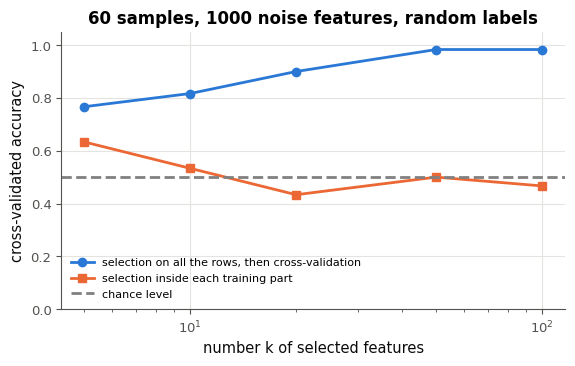

✅ Ex 8.25 : sélectionnées dans chaque tour, les features ne font pas mieux que le hasard, comme il se doit sur du bruit.


In [55]:
def top_k_25(X, y, k):
    """Indices of the k columns of X whose correlation with y is the largest in absolute value."""
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    r = (Xc * yc[:, None]).sum(axis=0) / np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    return np.argsort(-np.abs(r))[:k]


def selected_before_25(X, y, k):
    """Select the k features on ALL the rows, then the mean of cross_val_score(NearestCentroid(), ..., cv=5)."""
    columns = top_k_25(X, y, k)                                   # the leak: the validation rows take part
    return float(np.mean(mylearn.model_selection.cross_val_score(NearestCentroid(), X[:, columns], y, cv=5)))


def selected_inside_25(X, y, k):
    """For each split of kfold_indices(len(X), 5): select the k features on the training part only, fit
    NearestCentroid on them, score it on the validation part. Returns the mean of the 5 scores."""
    scores = []
    for train_idx, val_idx in mylearn.model_selection.kfold_indices(len(X), 5):
        columns = top_k_25(X[train_idx], y[train_idx], k)
        model = NearestCentroid().fit(X[train_idx][:, columns], y[train_idx])
        scores.append(model.score(X[val_idx][:, columns], y[val_idx]))
    return float(np.mean(scores))


if True:
    before_25 = selected_before_25(X_25, y_25, 20)
    inside_25 = selected_inside_25(X_25, y_25, 20)
    if not (returned("8.25", "selected_before_25", before_25) and returned("8.25", "selected_inside_25", inside_25)):
        pass
    elif not all(isinstance(value, (int, float)) for value in (before_25, inside_25)):
        print(f"❌ Ex 8.25 : les deux fonctions doivent renvoyer une accuracy moyenne (un nombre), reçu "
              f"{type(before_25).__name__} et {type(inside_25).__name__}.")
    else:
        print(f"k = 20: selection before the cross-validation {float(before_25):.3f}, inside {float(inside_25):.3f}")
        print_answer("8.25a", before_25, computed=True)
        print_answer("8.25b", inside_25, computed=True)
        ks_25 = [5, 10, 20, 50, 100]
        curves_25 = [(selected_before_25(X_25, y_25, k), selected_inside_25(X_25, y_25, k)) for k in ks_25]
        fig, ax = plt.subplots(figsize=(6.5, 3.6))
        ax.plot(ks_25, [b for b, _ in curves_25], "o-", label="selection on all the rows, then cross-validation")
        ax.plot(ks_25, [i for _, i in curves_25], "s-", label="selection inside each training part")
        ax.axhline(0.5, color="gray", ls="--", label="chance level")
        ax.set(xscale="log", xlabel="number k of selected features", ylabel="cross-validated accuracy", ylim=(0, 1.05),
               title="60 samples, 1000 noise features, random labels")
        ax.legend(fontsize=8)
        plt.show()
        verdict("8.25", all(0.25 <= i <= 0.75 for _, i in curves_25),
                "sélectionnées dans chaque tour, les features ne font pas mieux que le hasard, comme il se doit sur du bruit.",
                "avec la sélection dans chaque tour, l'accuracy devrait rester proche de 0,5 : vérifie que top_k_25 "
                "ne voit que la partie d'entraînement.")

In [56]:
wb.record("8.25a", before_25, decimals=4, mistakes={"c'est le score de la sélection faite dans chaque tour (question b)": inside_25})
wb.record("8.25b", inside_25, decimals=4, mistakes={"c'est le score de la sélection faite sur toutes les lignes (question a)": before_25})

WB_ANSWER {"decimals": 4, "hash": "fce565f0240b81c3bb8f9749939e630d694128e787c3f6563439af147b1648f0", "hash_coarse": "157dff83863b615b81de0b0315c3cce4710a187e92932a56ba24533c975cf903", "id": "8.25a", "kind": "float", "magnitude": -1, "mistakes": {"69968349c58f31a9652e7d5474e46dfd1a6edcba7ab96a70401de187d4a82cbf": "c'est le score de la sélection faite dans chaque tour (question b)"}, "sign": 1}
📝 Ex 8.25a : réponse enregistrée (float, 4 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "610554b185fd03b9e2dc85cde789f011cd85fe6561287bcdd4edffb1fdd171fa", "hash_coarse": "957f6fb3f3aa0567ec79b0a5e047632ddf52e165665c3427a93a79f2f34de715", "id": "8.25b", "kind": "float", "magnitude": -1, "mistakes": {"8cf17f1759d33dfc755f22256e35a7167730087e69cb69e23ac1275d12194b46": "c'est le score de la sélection faite sur toutes les lignes (question a)"}, "sign": 1}
📝 Ex 8.25b : réponse enregistrée (float, 4 décimale(s)).


💡 Sélectionnées sur toutes les lignes, les 20 features les plus corrélées au label le sont **aussi** avec les labels des lignes de validation : parmi 1 000 features de bruit, certaines s'alignent par hasard sur les 60 labels, et la sélection les trouve. La validation croisée note alors un modèle qui a déjà vu, par la sélection, ce qu'il devait prédire : 0,900. Sélectionnées dans chaque tour, elles ne disent rien des lignes de validation : 0,433, le niveau du hasard (à la variabilité près, avec 12 lignes par fold). Plus $k$ est grand, plus la sélection capture de hasard (0,77 pour $k = 5$, 0,98 pour $k = 50$). Un tel article doit dire **où** la sélection a eu lieu : c'est l'erreur relevée par Ambroise et McLachlan (2002). Un `Pipeline` contient la sélection : `cross_val_score` la refait dans chaque tour, comme `IslandPipeline` en 8.24 (15.24 refait cette expérience).

### Ex 8.26 — Comparer deux modèles honnêtement : test par permutation, p-valeur et bootstrap apparié 🔬 ★★★ ⏱️ 40 min
**Objectif :** décider si un modèle en bat vraiment un autre sur le même jeu de test, avec un test par permutation et un intervalle bootstrap apparié.  
**Prérequis :** Ex 8.22 · ch. 2 (bootstrap, 2.22 à 2.24) · fiche §8.6 (encadré 🧮 sur le test par permutation) · **Fil rouge :** Penguins · **Parcours :** R, M, C

Deux centroïdes les plus proches, entraînés sur les 233 manchots du ch. 1 et notés sur les 100 du test : **A** utilise la longueur et l'épaisseur du bec, standardisées ; **B** les quatre mesures, standardisées. `correct_A_26` et `correct_B_26` valent 1 pour chaque manchot de test bien classé, 0 sinon. B fait 0,98, A 0,95 : B est-il vraiment meilleur ?

a) `discordant_26` : la liste `[nombre de manchots de test où seul A a raison, nombre où seul B a raison]`.

Écris ensuite, avec $d_i$ = `correct_b[i] - correct_a[i]` (fiche §8.6) :
- `permutation_pvalue_26(correct_a, correct_b, n_perm=10_000, seed=826)` : `rng = np.random.default_rng(seed)`, puis **un seul** tirage `flips = rng.random((n_perm, n)) < 0.5` ; chaque ligne de `flips` change le signe des $d_i$ où elle vaut `True` ; compte les lignes dont la somme, en valeur absolue, est au moins égale à $|\sum_i d_i|$ (travaille avec ces sommes **entières**, pas avec des moyennes, pour éviter les pièges d'arrondi), et renvoie $(\text{compte} + 1) / (n_{\text{perm}} + 1)$ ;
- `paired_bootstrap_26(correct_a, correct_b, n_boot=10_000, seed=8260)` : `rng = np.random.default_rng(seed)`, puis **un seul** tirage `rows = rng.integers(0, n, size=(n_boot, n))` ; chaque ligne de `rows` est un rééchantillon des manchots de test (avec remise), dont on calcule l'écart d'accuracy B − A ; renvoie les percentiles 2,5 et 97,5 de ces écarts (`np.percentile`).

La vérification contrôle, pour la comparaison 1 (A, puis B) :
b) la p-valeur ;
c) l'intervalle à 95 % de l'écart B − A ;
puis la compare à la p-valeur exacte du test de McNemar (`scipy.stats.binomtest` sur les désaccords), et contrôle, pour la comparaison 2 (les quatre mesures **brutes**, puis B) :
d) la p-valeur.
e) `significant_26` : d'après b) et c), B bat-il A au seuil de 5 % ? (`True` ou `False`)

Dans tes notes : pourquoi seuls les désaccords comptent-ils ? Que veut dire la p-valeur de b), et que ne veut-elle **pas** dire ? Combien de manchots de test faudrait-il, à peu près, pour départager A et B ? Pourquoi la p-valeur de d) ne peut-elle pas descendre sous $1 / 10\,001$ ?

In [57]:
Z_26 = (X_peng - X_peng[TRAIN_CH1].mean(axis=0)) / X_peng[TRAIN_CH1].std(axis=0)   # standardised with the training rows


def correct_26(columns, standardised=True):
    """1 where NearestCentroid, trained on the 233 training penguins of ch. 1, is right on a test penguin, else 0."""
    A = (Z_26 if standardised else X_peng)[:, columns]
    model = NearestCentroid().fit(A[TRAIN_CH1], species[TRAIN_CH1])
    return (model.predict(A[TEST_CH1]) == species[TEST_CH1]).astype(int)


correct_A_26 = correct_26([0, 1])                       # A: bill length and depth, standardised
correct_B_26 = correct_26([0, 1, 2, 3])                 # B: the four measurements, standardised
correct_raw_26 = correct_26([0, 1, 2, 3], standardised=False)   # the four raw measurements (comparison 2)
print("accuracies on the 100 test penguins: A", correct_A_26.mean(), "· B", correct_B_26.mean(),
      "· four raw measurements", correct_raw_26.mean())

accuracies on the 100 test penguins: A 0.95 · B 0.98 · four raw measurements 0.67


In [58]:
discordant_26 = [int(np.sum((correct_A_26 == 1) & (correct_B_26 == 0))),
                 int(np.sum((correct_A_26 == 0) & (correct_B_26 == 1)))]


def permutation_pvalue_26(correct_a, correct_b, n_perm=10_000, seed=826):
    """Two-sided p-value of the paired permutation test of the fiche (sign flips of d = correct_b - correct_a)."""
    d = np.asarray(correct_b, dtype=int) - np.asarray(correct_a, dtype=int)
    rng = np.random.default_rng(seed)
    flips = rng.random((n_perm, len(d))) < 0.5                 # one draw: True = swap the answers of A and B
    sums = np.where(flips, -d, d).sum(axis=1)                  # integers: no rounding problem in the comparison
    return (1 + int(np.sum(np.abs(sums) >= abs(int(d.sum()))))) / (n_perm + 1)


def paired_bootstrap_26(correct_a, correct_b, n_boot=10_000, seed=8260):
    """95 % percentile interval [low, high] of the accuracy difference B - A, test penguins resampled with replacement."""
    d = np.asarray(correct_b, dtype=float) - np.asarray(correct_a, dtype=float)
    rng = np.random.default_rng(seed)
    rows = rng.integers(0, len(d), size=(n_boot, len(d)))     # one draw: one resample per row
    return np.percentile(d[rows].mean(axis=1), [2.5, 97.5])


significant_26 = False

print_answer("8.26a", discordant_26)
if True:
    p_value_26 = permutation_pvalue_26(correct_A_26, correct_B_26)
    interval_26 = paired_bootstrap_26(correct_A_26, correct_B_26)
    if not (returned("8.26", "permutation_pvalue_26", p_value_26) and returned("8.26", "paired_bootstrap_26", interval_26)):
        pass
    elif not isinstance(p_value_26, (int, float)) or np.shape(interval_26) != (2,):
        print(f"❌ Ex 8.26 : permutation_pvalue_26 doit renvoyer un nombre et paired_bootstrap_26 deux bornes [low, high] ; "
              f"reçu {type(p_value_26).__name__} et un objet de forme {np.shape(interval_26)}.")
    else:
        print(f"comparison 1 (A, then B): p-value {float(p_value_26):.4f}, 95 % interval of B − A:",
              np.round(np.asarray(interval_26, dtype=float), 3).tolist())
        print_answer("8.26b", p_value_26, computed=True)
        print_answer("8.26c", interval_26, computed=True)
        only_a_26 = int(np.sum((correct_A_26 == 1) & (correct_B_26 == 0)))
        only_b_26 = int(np.sum((correct_A_26 == 0) & (correct_B_26 == 1)))
        exact_26 = scipy.stats.binomtest(min(only_a_26, only_b_26), only_a_26 + only_b_26, 0.5).pvalue
        verdict("8.26", abs(float(p_value_26) - exact_26) < 0.02,
                f"proche de la p-valeur exacte du test de McNemar ({fr(exact_26, 4)}).",
                f"la p-valeur exacte du test de McNemar vaut {fr(exact_26, 4)} : la tienne devrait en être proche.")
        p_value_raw_26 = permutation_pvalue_26(correct_raw_26, correct_B_26)
        print(f"comparison 2 (raw measurements, then B): p-value {float(p_value_raw_26):.4f}")
        print_answer("8.26d", p_value_raw_26, computed=True)
print_answer("8.26e", significant_26)

8.26a: [0, 3]
comparison 1 (A, then B): p-value 0.2482, 95 % interval of B − A: [0.0, 0.07]
8.26b: 0.24817518248175183
8.26c: [0.0, 0.07]
✅ Ex 8.26 : proche de la p-valeur exacte du test de McNemar (0,2500).
comparison 2 (raw measurements, then B): p-value 0.0001
8.26d: 9.999000099990002e-05
8.26e: False


In [59]:
d_26 = correct_B_26 - correct_A_26
sums_26 = np.where(np.random.default_rng(826).random((10_000, 100)) < 0.5, -d_26, d_26).sum(axis=1)
one_sided_26 = (1 + int(np.sum(sums_26 >= d_26.sum()))) / 10_001
count_26 = round(p_value_26 * 10_001) - 1
wb.record("8.26a", discordant_26, mistakes={"l'ordre demandé est [seul A a raison, seul B a raison]": discordant_26[::-1]})
wb.record("8.26b", p_value_26, decimals=4, mistakes={"c'est une p-valeur unilatérale : le test de la fiche compte |somme| ≥ |écart observé|, dans les deux sens": one_sided_26,
                                                     "applique la formule de l'énoncé : (compte + 1) / (n_perm + 1), pas compte / n_perm": count_26 / 10_000})
wb.record("8.26c", interval_26, decimals=4, mistakes={"c'est l'intervalle de A − B : la question demande l'écart B − A": [-interval_26[1], -interval_26[0]]})
wb.record("8.26d", p_value_raw_26, decimals=4, mistakes={"une p-valeur par permutation ne vaut jamais 0 : la formule de l'énoncé ajoute 1 au compte et au nombre de permutations": 0.0})
wb.record("8.26e", significant_26, mistakes={"compare la p-valeur de b) à 0,05, et regarde si l'intervalle de c) contient 0": True})

WB_ANSWER {"decimals": 0, "element_hashes": ["0fda8c18a40eec305407dc592edd4c8c75a2812bc2f2cfd6a4e21748447e4866", "9b77c2c8fd48ffbefaa65e89d9d218df6fa11bfa1d73f252b5ce44032776f264"], "hash": "4c3ab4811d068c8f2cb990a4c9f21f82acec7720802c95d6acfe47f92c48fd74", "id": "8.26a", "integer": true, "kind": "array", "mistakes": {"27e0f71a371625971070285373ff5af2aca4080559f098277a4686932a8c19ea": "l'ordre demandé est [seul A a raison, seul B a raison]"}, "shape": [2]}
📝 Ex 8.26a : réponse enregistrée (array, 0 décimale(s)).
WB_ANSWER {"decimals": 4, "hash": "51e16f66fb9f5d1f2272a7dc7f5ee04abd4e6a2860eccb9f04fd0d57ea5cdc05", "hash_coarse": "cd46c0904763300214e5769ee6ce98d847bb6fa7b32aec05fb138fa4adc35aa2", "id": "8.26b", "kind": "float", "magnitude": -1, "mistakes": {"c849114f7a864f495dc1105b5998111632d30ed3aa6f539ff6bb471f5f3b2def": "applique la formule de l'énoncé : (compte + 1) / (n_perm + 1), pas compte / n_perm", "f929fb42a5f2a4c48b720fab9f20b163ff90ef8543b7f076fe939cc94923f33b": "c'est une p-

💡 A et B ne sont en désaccord que sur 3 manchots, et B a raison les 3 fois : $\sum_i d_i = 3$. Sous l'hypothèse nulle, ces trois désaccords tombent du côté de B ou de A à pile ou face, et $|D| = 3$ arrive dans 2 cas sur 8 : la p-valeur exacte vaut 0,25 (McNemar), la permutation donne 0,248. L'intervalle bootstrap va de 0 à 0,07 : il touche 0. Conclusion : rien ne permet de dire que B est meilleur que A avec 100 manchots de test (`significant_26 = False`). Ce n'est pas une preuve que A et B se valent : il faudrait plus de désaccords, donc un test bien plus grand (avec la même proportion de désaccords, au moins 6 désaccords tous favorables à B, soit environ deux fois plus de manchots, pour descendre sous 0,05). Contre les mesures brutes (0,67), B gagne les 31 désaccords : aucune des 10 000 permutations n'atteint 31, et la p-valeur vaut son minimum, $1/10\,001 \approx 0{,}0001$.

### Ex 8.27 — Défi : la meilleure paire de features, choisie sans toucher au test 🏆 ★★★ ⏱️ 60 min
**Objectif :** choisir un modèle avec les seules données d'entraînement, et le valider une seule fois sur le test.  
**Prérequis :** Ex 8.22 · Ex 8.21 · Ex 8.12 · fiche §8.4 et §8.5 · **Fil rouge :** Penguins · **Parcours :** C

Prédis le **sexe** d'un manchot à partir de **deux** de ses quatre mesures. Les candidats : une paire de colonnes de `X_peng` (6 paires), standardisée ou non, puis le centroïde le plus proche (`"centroid"`) ou le plus proche voisin (`"1-NN"`), soit 24 candidats, que `PairModel(columns, standardize, model)` (fourni) sait construire. Les règles :
- tu écris `choose_27(X_train, y_train)`, qui renvoie le triplet `(columns, standardize, model)` choisi à partir des **seuls** manchots d'entraînement qu'elle reçoit ;
- le test du ch. 1 (100 manchots) n'est révélé qu'**une fois** par session, quand tu mets `READY_27 = True` : si tu changes ensuite d'avis, ta note reste celle du premier choix (comme sur une plateforme de compétition, le score de test ne sert pas à choisir) ;
- `grade_27` relance aussi ta fonction sur 20 autres découpages des 333 manchots (233 + 100) : ta **méthode** doit tenir, pas seulement ton choix.

**Objectif : une accuracy d'au moins 0,90 sur le test du ch. 1, et d'au moins 0,86 en moyenne sur les 20 autres découpages.** Le point de départ fourni choisit le candidat qui a la meilleure accuracy **d'entraînement** : il n'y arrive pas (pourquoi ? relis 8.12).

Dans tes notes : ta méthode, le candidat choisi, et pourquoi le point de départ échoue. Pourquoi la paire choisie est-elle plausible, d'après ce que tu sais des manchots (les mâles sont plus lourds, à espèce égale) ?

In [60]:
sex = penguins["sex"].to_numpy()                     # "male" or "female"


class PairModel:
    """Two of the four measurements, standardised or not (statistics of the rows given to fit), then
    NearestCentroid ("centroid") or OneNN ("1-NN")."""

    def __init__(self, columns=(0, 1), standardize=True, model="centroid"):
        self.columns = columns
        self.standardize = standardize
        self.model = model

    def fit(self, X, y):
        A = np.asarray(X, dtype=float)[:, list(self.columns)]
        self.mean_ = A.mean(axis=0) if self.standardize else np.zeros(A.shape[1])
        self.std_ = A.std(axis=0) if self.standardize else np.ones(A.shape[1])
        model = NearestCentroid() if self.model == "centroid" else OneNN()
        self.model_ = model.fit((A - self.mean_) / self.std_, y)
        return self

    def predict(self, X):
        A = np.asarray(X, dtype=float)[:, list(self.columns)]
        return self.model_.predict((A - self.mean_) / self.std_)

    def score(self, X, y):
        return float(np.mean(self.predict(X) == np.asarray(y)))


TEST_27 = {"first": None}                             # the test of ch. 1 is revealed once per session


def _check_choice_27(choice):
    """(columns, standardize, model) cleaned up, or (None, the reason why the choice is not valid)."""
    if not (isinstance(choice, (tuple, list)) and len(choice) == 3):
        return None, f"choose_27 doit renvoyer un triplet (columns, standardize, model), pas {choice!r}"
    columns, standardize, model = choice
    try:
        columns = tuple(int(c) for c in columns)
    except (TypeError, ValueError):
        return None, f"columns doit être une paire d'indices de colonnes, pas {columns!r}"
    if len(columns) != 2 or len(set(columns)) != 2 or not all(0 <= c < 4 for c in columns):
        return None, f"columns doit contenir deux indices différents parmi 0, 1, 2 et 3, pas {columns}"
    if model not in ("centroid", "1-NN"):
        return None, f'model doit valoir "centroid" ou "1-NN", pas {model!r}'
    return (columns, bool(standardize), model), ""


def grade_27(choose, reveal):
    """(result, reason): choose_27 on the 233 training penguins of ch. 1; with reveal=True, the test accuracy of the
    choice (shown once per session), then the mean test accuracy of choose_27 rerun on 20 other splits."""
    choice, reason = _check_choice_27(choose(X_peng[TRAIN_CH1].copy(), sex[TRAIN_CH1].copy()))
    if choice is None:
        return None, reason
    print("your choice on the 233 training penguins:", choice)
    if not reveal:
        return None, "le test n'est pas encore révélé : mets READY_27 = True quand ton choix est arrêté"
    if TEST_27["first"] is None:
        main = PairModel(*choice).fit(X_peng[TRAIN_CH1], sex[TRAIN_CH1]).score(X_peng[TEST_CH1], sex[TEST_CH1])
        TEST_27["first"] = (choice, main)
    elif TEST_27["first"][0] != choice:
        print("⚠️ le test du ch. 1 a déjà été révélé dans cette session : la note reste celle de ton premier choix,",
              TEST_27["first"][0])
    first_choice, main = TEST_27["first"]
    others = []
    for seed in range(2700, 2720):                    # 20 other splits of the 333 penguins (233 + 100)
        order = np.random.default_rng(seed).permutation(len(sex))
        test, train = order[:100], order[100:]
        other, reason = _check_choice_27(choose(X_peng[train].copy(), sex[train].copy()))
        if other is None:
            return None, reason
        others.append(PairModel(*other).fit(X_peng[train], sex[train]).score(X_peng[test], sex[test]))
    return {"choice": first_choice, "test": main, "others": float(np.mean(others))}, ""

In [61]:
def choose_27(X_train, y_train):
    """Choose (columns, standardize, model) to predict the sex of a penguin, with the training penguins only."""
    candidates = [(columns, standardize, model) for columns in itertools.combinations(range(4), 2)
                  for standardize in (False, True) for model in ("centroid", "1-NN")]
    folds = mylearn.model_selection.stratified_kfold_indices(y_train, n_splits=5, shuffle=True,
                                                             rng=np.random.default_rng(27))
    scores = [np.mean(mylearn.model_selection.cross_val_score(PairModel(*candidate), X_train, y_train, cv=folds))
              for candidate in candidates]
    return candidates[int(np.argmax(scores))]


READY_27 = True

if True:
    with threadpool_limits(limits=1):
        result_27, reason_27 = grade_27(choose_27, READY_27)
    if result_27 is None:
        print(f"⏳ Ex 8.27 : {reason_27}." if "révélé" in reason_27 else f"❌ Ex 8.27 : {reason_27}.")
    else:
        print(f"test of ch. 1 (100 penguins): {result_27['test']:.2f} · mean of the 20 other splits: {result_27['others']:.3f}")
        verdict("8.27", result_27["test"] >= 0.90, f"accuracy de {fr(result_27['test'], 2)} sur le test : objectif atteint.",
                f"accuracy de {fr(result_27['test'], 2)} sur le test : il faut au moins 0,90.")
        verdict("8.27", result_27["others"] >= 0.86,
                f"ta méthode tient sur 20 autres découpages (moyenne {fr(result_27['others'], 3)}).",
                f"sur 20 autres découpages, ta méthode n'obtient que {fr(result_27['others'], 3)} en moyenne : il faut "
                "au moins 0,86.")

your choice on the 233 training penguins: ((1, 3), True, 'centroid')


test of ch. 1 (100 penguins): 0.91 · mean of the 20 other splits: 0.876
✅ Ex 8.27 : accuracy de 0,91 sur le test : objectif atteint.
✅ Ex 8.27 : ta méthode tient sur 20 autres découpages (moyenne 0,876).


💡 Le point de départ échoue : l'accuracy d'entraînement de tout plus proche voisin vaut 1 (8.12), et il retient donc le premier 1-NN de la liste (longueur et épaisseur du bec, brutes), qui fait 0,81 sur le test. Une validation croisée stratifiée (5 folds, mélangée) sur les 233 manchots d'entraînement retient l'épaisseur du bec et la masse, standardisées, avec le centroïde le plus proche (0,880 en validation croisée, contre 0,832 pour le candidat suivant) : 0,91 sur le test, et 0,876 en moyenne sur les 20 autres découpages. Les variantes honnêtes (folds non mélangés, 10 folds, k-fold répétée) font le même choix. La masse et l'épaisseur du bec séparent bien les sexes **à l'intérieur** de chaque espèce (les mâles sont plus lourds et ont un bec plus épais), et la standardisation les met à la même échelle : sans elle, la masse, en grammes, écraserait tout le reste.

## ✅ Bilan

**Auto-évaluation** (note-toi de 0 à 3 dans `mon_travail/suivi/auto_evaluation.md`) :
1. Sais-tu dire, pour chaque jeu (entraînement, validation, test), à quoi il sert et ce qu'on n'a pas le droit d'en faire ?
2. Sais-tu repérer une fuite dans un protocole (prétraitement, sélection, choix sur le test, doublons, données dépendantes) et la corriger ?
3. Sais-tu dire si un écart entre deux scores est significatif, et choisir entre hold-out et validation croisée ?

**Pour aller plus loin** : les guides « Cross-validation » et « Common pitfalls and recommended practices » de scikit-learn, cités dans la fiche. La suite : le ch. 9 (overfitting et underfitting), où ta `cross_val_score` choisira la régularisation, et les courbes d'apprentissage montreront l'écart entre entraînement et validation.